In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from shapely import wkt 
from shapely.geometry import Point
from shapely.geometry import box
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose
# import contextily as ctx
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans

import glob
import os
import csv
import ast
import matplotlib.patheffects as path_effects
from matplotlib.ticker import PercentFormatter

# from libpysal import weights

from matplotlib.colors import (
    ListedColormap,
    BoundaryNorm,
    LinearSegmentedColormap,
    TwoSlopeNorm
)

from pathlib import Path

In [2]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)

### Read in source files 

In [3]:
# study area gdfs 
new_ea = gpd.read_file(DATA_DIR / 'miscellaneous/new_ea.json')
new_data_study_area = gpd.read_file(DATA_DIR / 'miscellaneous/new_data_study_area.json')

# PQR sites 
new_sites = gpd.read_file(DATA_DIR / 'miscellaneous/new_sites.json')

# shapefile (all EAs)
filt_all_eas_dem_df = gpd.read_file(DATA_DIR / 'miscellaneous/filt_all_eas_dem_df.json')

### Mapping of EAs and PQR sites 

In [4]:
ea_copy_pqr = new_ea.copy()
ea_copy_pqr = ea_copy_pqr[['ea_code9ch', 'geometry']]
merged_sites_pqr = gpd.sjoin(new_sites, ea_copy_pqr, how = 'inner', predicate = 'intersects')

merged_sites_pqr = merged_sites_pqr[['space_grouping', 'geometry', 'ea_code9ch']].reset_index(drop=True)

grouped_sites_df = merged_sites_pqr.groupby('ea_code9ch').agg({
    'space_grouping': lambda x: list(set(x)),  
})

grouped_sites_df = grouped_sites_df.rename(columns = {'space_grouping':'site_id'})

### 2021 Census Districts 

In [5]:
# read districts shapefile for plotting 
dist_2021 = gpd.read_file(DATA_DIR / 'miscellaneous/district_2021_census.geojson')

In [6]:
### Filter out Study Area Districts 

dist_2021 = gpd.sjoin(
    dist_2021, merged_sites_pqr.to_crs('EPSG:4326'), 
    how="inner", 
    predicate='contains' 
).reset_index(drop=True).drop(columns=['index_right'])

dist_2021 = dist_2021.drop_duplicates(['Name']).reset_index(drop=True)

# reproject to local CRS 
dist_2021_transformed = dist_2021.to_crs(merged_sites_pqr.crs)

district_gdf = dist_2021_transformed.copy()

### Revised EA shapefile  

In [7]:
filt_all_eas_dem_df_filt = gpd.sjoin(
    filt_all_eas_dem_df, dist_2021_transformed.drop(columns = ['ea_code9ch']), 
    how="inner", 
    predicate='intersects' 
).reset_index(drop=True)

## exclude additional EAs around the edges for basemap plotting 
additional_eas_to_exclude = [31400149, 31400142, 31400139, 31400134, 31400133, 30801173, 30801139, 30801138, 30801136, 30801063, 30801062, 30100656, 30100652, 30200407, 30200368, 30801041, 30801001, 30100689, 30200426]

filt_all_eas_dem_df_filt = filt_all_eas_dem_df_filt[
    ~filt_all_eas_dem_df_filt['ea_code9ch'].isin(additional_eas_to_exclude)
]

### EAs n Sites  (6km) 

In [8]:
merged_eas_sites = pd.read_csv(DATA_DIR / 'miscellaneous/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

### Read EAs and CESI level `rev_1`

In [9]:
eas_n_cesi_level = pd.read_csv(DATA_DIR / 'miscellaneous/eas_cesi_level_214_eas_rev1.csv').drop(columns = ['Unnamed: 0'])

### Merged sites & (214 EAs) 

In [10]:
merged_eas_sites = merged_eas_sites.merge(eas_n_cesi_level, on = 'ea_code9ch').reset_index(drop=True)

In [11]:
# merged_eas_sites

### Explode the site_ids 

In [12]:
merged_eas_sites_exploded = (
    merged_eas_sites
    .explode('Intersecting_Sites', ignore_index=True)
    .rename(columns={'Intersecting_Sites': 'site_id'})
)

merged_eas_sites_exploded['site_id'] = (merged_eas_sites_exploded['site_id'].astype('Int64'))

merged_eas_sites_exploded.head()

,ea_code9ch,site_id,cesi_level
0,30200002,456,Low
1,30200012,430,Low
2,30200013,363,Low
3,30200014,301,Low
4,30200015,104,Low


### filter & get site geometries from main `sample df` 

In [13]:
df = pd.read_csv(DATA_DIR / 'miscellaneous/2022-05-01.csv')

df = df[['time', 'respondent_id', 'site_latitude', 'site_longitude', 'voltage', 'frequency', 'site_id']]

In [14]:
site_coords = (
    df.groupby('site_id')[['site_latitude', 'site_longitude']]
      .first()
      .reset_index()
)

merged_df = merged_eas_sites_exploded.merge(
    site_coords,
    on='site_id',
    how='left'
)

In [15]:
merged_df.head()

,ea_code9ch,site_id,cesi_level,site_latitude,site_longitude
0,30200002,456,Low,5.633024,-0.300601
1,30200012,430,Low,5.638675,-0.300250
2,30200013,363,Low,5.640099,-0.291457
3,30200014,301,Low,5.636135,-0.286370
4,30200015,104,Low,5.644859,-0.290894


In [16]:
merged_df[merged_df['ea_code9ch'] == 30200263]

,ea_code9ch,site_id,cesi_level,site_latitude,site_longitude
34,30200263,351,Low,5.666025,-0.297281
35,30200263,231,Low,NaN,NaN


### read in 1- & 3-day overlap summary df 

In [17]:
ea_1_3_day_risk_flags = pd.read_csv(DATA_DIR / 'miscellaneous/ea_1_3_day_risk_flags.csv').drop(columns = ['Unnamed: 0'])

In [18]:
ea_1_3_day_risk_flags.head()

,ea_code9ch,event,one_day_risk,three_day_risk,both
0,30200126,L,0,1,0
1,30200184,L,0,1,0
2,30200198,L,1,0,0
3,30200204,L,0,1,0
4,30200266,L,1,0,0


### Merge with the EA & sites df 

In [19]:
merged_risk_df = (
    merged_df
    .merge(
        ea_1_3_day_risk_flags,
        on='ea_code9ch',
        how='left',
        validate='many_to_many'
    )
)

risk_cols = ['one_day_risk', 'three_day_risk', 'both']

merged_risk_df[risk_cols] = (
    merged_risk_df[risk_cols]
    .fillna(0)
    .astype(int)
)

In [20]:
merged_risk_df

,ea_code9ch,site_id,cesi_level,site_latitude,site_longitude,event,one_day_risk,three_day_risk,both
0,30200002,456,Low,5.633024,-0.300601,NaN,0,0,0
1,30200012,430,Low,5.638675,-0.300250,NaN,0,0,0
2,30200013,363,Low,5.640099,-0.291457,NaN,0,0,0
3,30200014,301,Low,5.636135,-0.286370,P,0,1,0
4,30200015,104,Low,5.644859,-0.290894,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...
251,31300310,117,Low,5.689682,-0.186315,W,1,0,0
252,31300328,296,Low,5.711324,-0.185577,NaN,0,0,0
253,31300407,445,Low,5.711772,-0.188362,NaN,0,0,0
254,31300449,228,Low,5.659560,-0.167445,NaN,0,0,0


In [21]:
merged_risk_df = merged_risk_df[['ea_code9ch', 'cesi_level', 'event', 'one_day_risk', 'three_day_risk', 'both']].reset_index(
                                                                                                drop=True)

merged_risk_df_w_geoms = merged_risk_df.merge(filt_all_eas_dem_df_filt[['ea_code9ch', 'geometry']], on = 'ea_code9ch', how = 'left').drop_duplicates(subset=['ea_code9ch', 'event'])
merged_risk_df_w_geoms = merged_risk_df_w_geoms.reset_index(drop=True)

merged_risk_gdf = gpd.GeoDataFrame(
    merged_risk_df_w_geoms.copy(),
    geometry="geometry",
    crs="EPSG:32630"
)

In [22]:
merged_risk_gdf

,ea_code9ch,cesi_level,event,one_day_risk,three_day_risk,both,geometry
0,30200002,Low,NaN,0,0,0,"POLYGON ((799017.814 623458.371, 799051.565 62..."
1,30200012,Low,NaN,0,0,0,"POLYGON ((799328.799 623914.862, 799292 623916..."
2,30200013,Low,NaN,0,0,0,"POLYGON ((799909.133 624452.948, 799919.44 624..."
3,30200014,Low,P,0,1,0,"POLYGON ((800503.736 624455.809, 800569.516 62..."
4,30200015,Low,NaN,0,0,0,"POLYGON ((799640.296 624891.197, 799654.316 62..."
...,...,...,...,...,...,...,...
224,31300291,High,NaN,0,0,0,"POLYGON ((813765.805 629305.242, 813853.337 62..."
225,31300310,Low,W,1,0,0,"POLYGON ((811832.487 629333.217, 811643.775 62..."
226,31300328,Low,NaN,0,0,0,"POLYGON ((813036.279 631092.941, 813016.813 63..."
227,31300407,Low,NaN,0,0,0,"POLYGON ((811220.071 632428, 811219.23 632385...."


## Visualize 

### Define x&y offsets, figsize, and x&y axis limits - so the spatial figures are more centered

In [23]:
common_x_ref_offset = 4     # km east if use_km=True
common_y_ref_offset = -1 

fig_size=(10, 8)

common_xlim = (-18, 18)
common_ylim = (-12, 22)

In [24]:
def plot_ea_risk_distances(
    gdf,
    base_gdf=None,

    # Column names
    ea_col="ea_code9ch",
    event_col="event",

    # Event selection
    event_filter=None,
    show_cross_event=False,

    # Reference point
    use_union_centroid=True,
    ref_easting=None,
    ref_northing=None,
    x_ref_offset=0,
    y_ref_offset=0,
    use_km=True,

    # Basemap
    show_basemap=False,
    basemap_facecolor="none",
    basemap_edgecolor="lightgrey",
    basemap_linewidth=0.4,
    basemap_alpha=1.0,

    # Figure
    figsize=(10, 8),

    # Point styling
    point_size=75,
    point_alpha=0.9,
    point_edgecolor="white",
    point_linewidth=0.7,

    # Risk colors
    one_day_color="#2878A5",
    three_day_color="#E68613",
    both_color="#7B2CBF",
    cross_event_color="#7F7F7F",

    # Legend labels
    one_day_label="Same-day",
    three_day_label="3-day window",
    both_label="Both",
    cross_event_label=(
        "Same- and 3-day risk, different events"
    ),

    # Reference lines
    show_reference_lines=True,
    reference_linecolor="black",
    reference_linestyle="--",
    reference_linewidth=1,
    reference_alpha=0.5,

    # Reference point marker
    show_reference_point=False,
    reference_point_size=80,
    reference_point_marker="X",
    reference_point_color="black",

    # Axes
    xlim=None,
    ylim=None,
    show_yaxis=False,
    equal_aspect=True,

    # Axis labels
    x_label=None,
    y_label=None,
    axis_label_fontsize=15,
    axis_label_fontweight="bold",
    axis_labelpad=12,

    # Tick labels
    x_tick_fontsize=12,
    y_tick_fontsize=12,
    x_rotation=0,

    # Annotation
    annotate=False,
    annotation_fontsize=8,

    # Panel label
    panel_label=None,
    panel_label_x=0.02,
    panel_label_y=0.98,
    panel_label_fontsize=16,
    panel_label_fontweight="bold",
    panel_label_ha="left",
    panel_label_va="top",

    # Title
    title=None,
    title_fontsize=15,
    title_fontweight="bold",
    title_pad=12,

    # Legend
    show_legend=True,
    legend_title=None,
    legend_loc="upper left",
    legend_bbox=None,
    legend_fontsize=12,
    legend_title_fontsize=12,
    legend_marker_size=10,
    legend_frame=True,
    legend_facecolor="white",
    legend_edgecolor="grey",
    legend_framealpha=0.9,

    # Diagnostics
    diagnostics=False,

    # Saving
    save_path=None,
    dpi=300
):
    """
    Plot EA centroids according to same-day and 3-day increased-risk
    categories.

    Parameters
    ----------
    gdf : GeoDataFrame
        Risk GeoDataFrame containing EA polygons and the columns:
        event, one_day_risk, three_day_risk, and both.

    base_gdf : GeoDataFrame or None
        Optional separate EA GeoDataFrame used as the basemap and
        for calculating the union-centroid reference point.

        If None, the EA polygons in `gdf` are used.

    event_filter : None, str, or list-like
        None:
            Combine all available events.

        str:
            Select one event, such as "T".

        list-like:
            Combine selected events, such as ["T", "P"].

    show_cross_event : bool
        If True, distinguish EAs where the same-day and 3-day risks
        occurred for different events.

        If False, all EAs having both risk durations are shown using
        the general "both" category.
    """

    import numpy as np
    import geopandas as gpd
    import matplotlib.pyplot as plt

    from matplotlib.lines import Line2D
    from shapely import affinity

    # =================================================
    # Helper: clean and dissolve an EA GeoDataFrame
    # =================================================
    def prepare_ea_polygons(input_gdf, name):
        prepared = gpd.GeoDataFrame(
            input_gdf.copy(),
            geometry="geometry",
            crs=getattr(input_gdf, "crs", None)
        )

        if prepared.crs is None:
            raise ValueError(
                f"{name} must have a defined CRS."
            )

        if prepared.crs.is_geographic:
            raise ValueError(
                f"{name} must use a projected CRS. "
                "For Greater Accra, use EPSG:32630."
            )

        required = {ea_col, "geometry"}
        missing = required - set(prepared.columns)

        if missing:
            raise ValueError(
                f"{name} is missing columns: "
                f"{sorted(missing)}"
            )

        prepared = prepared.dropna(
            subset=[ea_col, "geometry"]
        ).copy()

        prepared = prepared[
            ~prepared.geometry.is_empty
        ].copy()

        prepared[ea_col] = (
            prepared[ea_col]
            .astype(str)
            .str.strip()
        )

        invalid_mask = ~prepared.geometry.is_valid

        if invalid_mask.any():
            prepared.loc[
                invalid_mask,
                "geometry"
            ] = (
                prepared.loc[
                    invalid_mask,
                    "geometry"
                ]
                .buffer(0)
            )

        prepared = (
            prepared[[ea_col, "geometry"]]
            .dissolve(
                by=ea_col,
                as_index=False
            )
        )

        return gpd.GeoDataFrame(
            prepared,
            geometry="geometry",
            crs=input_gdf.crs
        )

    # =================================================
    # Prepare risk GeoDataFrame
    # =================================================
    risk_gdf = gpd.GeoDataFrame(
        gdf.copy(),
        geometry="geometry",
        crs=getattr(gdf, "crs", None)
    )

    required_risk_cols = {
        ea_col,
        event_col,
        "one_day_risk",
        "three_day_risk",
        "both",
        "geometry"
    }

    missing_risk_cols = (
        required_risk_cols - set(risk_gdf.columns)
    )

    if missing_risk_cols:
        raise ValueError(
            "gdf is missing required columns: "
            f"{sorted(missing_risk_cols)}"
        )

    if risk_gdf.crs is None:
        raise ValueError(
            "gdf must have a defined CRS."
        )

    if risk_gdf.crs.is_geographic:
        raise ValueError(
            "gdf must use a projected CRS. "
            "For Greater Accra, use EPSG:32630."
        )

    risk_gdf = risk_gdf.dropna(
        subset=[ea_col, "geometry"]
    ).copy()

    risk_gdf = risk_gdf[
        ~risk_gdf.geometry.is_empty
    ].copy()

    risk_gdf[ea_col] = (
        risk_gdf[ea_col]
        .astype(str)
        .str.strip()
    )

    risk_gdf[event_col] = (
        risk_gdf[event_col]
        .astype("string")
        .str.strip()
        .str.upper()
    )

    risk_cols = [
        "one_day_risk",
        "three_day_risk",
        "both"
    ]

    risk_gdf[risk_cols] = (
        risk_gdf[risk_cols]
        .fillna(0)
        .astype(int)
    )

    invalid_mask = ~risk_gdf.geometry.is_valid

    if invalid_mask.any():
        risk_gdf.loc[
            invalid_mask,
            "geometry"
        ] = (
            risk_gdf.loc[
                invalid_mask,
                "geometry"
            ]
            .buffer(0)
        )

    # One risk polygon per EA
    risk_polygons = prepare_ea_polygons(
        risk_gdf,
        name="gdf"
    )

    # =================================================
    # Prepare separate basemap, if supplied
    # =================================================
    if base_gdf is not None:
        basemap_polygons = prepare_ea_polygons(
            base_gdf,
            name="base_gdf"
        )

        # Match risk-data CRS
        if basemap_polygons.crs != risk_gdf.crs:
            basemap_polygons = (
                basemap_polygons.to_crs(
                    risk_gdf.crs
                )
            )

    else:
        basemap_polygons = risk_polygons.copy()

    # =================================================
    # Select events
    # =================================================
    available_events = sorted(
        risk_gdf[event_col]
        .dropna()
        .unique()
        .tolist()
    )

    if event_filter is None:
        selected_events = available_events

    elif isinstance(event_filter, str):
        selected_events = [
            event_filter.strip().upper()
        ]

    else:
        selected_events = [
            str(event).strip().upper()
            for event in event_filter
        ]

    missing_events = [
        event
        for event in selected_events
        if event not in available_events
    ]

    if missing_events:
        raise ValueError(
            f"Events not found: {missing_events}. "
            f"Available events are: {available_events}"
        )

    if not selected_events:
        raise ValueError(
            "No valid events are available for plotting."
        )

    selected = risk_gdf[
        risk_gdf[event_col].isin(
            selected_events
        )
    ].copy()

    # Retain only increased-risk rows
    selected = selected[
        selected[risk_cols].max(axis=1).eq(1)
    ].copy()

    if selected.empty:
        raise ValueError(
            "No increased-risk EAs were found for "
            "the selected event or events."
        )

    # =================================================
    # Collapse selected event rows to one row per EA
    # =================================================
    ea_risk = (
        selected
        .groupby(ea_col, as_index=False)
        .agg(
            one_day_risk=(
                "one_day_risk",
                "max"
            ),
            three_day_risk=(
                "three_day_risk",
                "max"
            ),
            both=(
                "both",
                "max"
            ),
            selected_event_count=(
                event_col,
                "nunique"
            )
        )
    )

    # Mutually exclusive risk categories
    conditions = [
        # Both risks within at least one identical event
        ea_risk["both"].eq(1),

        # Same-day only
        (
            ea_risk["one_day_risk"].eq(1)
            & ea_risk["three_day_risk"].eq(0)
        ),

        # 3-day only
        (
            ea_risk["one_day_risk"].eq(0)
            & ea_risk["three_day_risk"].eq(1)
        ),

        # Both durations, but across different events
        (
            ea_risk["one_day_risk"].eq(1)
            & ea_risk["three_day_risk"].eq(1)
            & ea_risk["both"].eq(0)
        )
    ]

    choices = [
        "both_same_event",
        "one_day_only",
        "three_day_only",
        "both_different_events"
    ]

    ea_risk["risk_category"] = np.select(
        conditions,
        choices,
        default="no_risk"
    )

    # Combine both categories unless requested separately
    if not show_cross_event:
        ea_risk.loc[
            ea_risk["risk_category"].eq(
                "both_different_events"
            ),
            "risk_category"
        ] = "both_same_event"

    # =================================================
    # Join risk results to EA polygons
    # =================================================
    ea_plot = risk_polygons.merge(
        ea_risk,
        on=ea_col,
        how="inner",
        validate="one_to_one"
    )

    ea_plot = gpd.GeoDataFrame(
        ea_plot,
        geometry="geometry",
        crs=risk_polygons.crs
    )

    if ea_plot.empty:
        raise ValueError(
            "No EA polygons matched the selected "
            "risk results."
        )

    # =================================================
    # Calculate EA centroids
    # =================================================
    ea_centroids = ea_plot.copy()

    ea_centroids["geometry"] = (
        ea_plot.geometry.centroid
    )

    ea_centroids["easting"] = (
        ea_centroids.geometry.x
    )

    ea_centroids["northing"] = (
        ea_centroids.geometry.y
    )

    # =================================================
    # Define reference point
    # =================================================
    if use_union_centroid:
        try:
            base_union = (
                basemap_polygons.geometry.union_all()
            )
        except Exception:
            base_union = (
                basemap_polygons.geometry.unary_union
            )

        reference_point = base_union.centroid

        ref_easting = reference_point.x
        ref_northing = reference_point.y

    else:
        if (
            ref_easting is None
            or ref_northing is None
        ):
            raise ValueError(
                "Provide both ref_easting and "
                "ref_northing when "
                "use_union_centroid=False."
            )

    # =================================================
    # Apply offsets and choose units
    # =================================================
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000

        conversion_factor = 1000
        unit_label = "km"

    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

        conversion_factor = 1
        unit_label = "m"

    # Coordinates relative to reference point
    ea_centroids["x_distance"] = (
        ea_centroids["easting"]
        - ref_easting
    ) / conversion_factor

    ea_centroids["y_distance"] = (
        ea_centroids["northing"]
        - ref_northing
    ) / conversion_factor

    # =================================================
    # Plotting configuration
    # =================================================
    category_styles = {
        "one_day_only": {
            "color": one_day_color,
            "label": one_day_label,
            "zorder": 3
        },
        "three_day_only": {
            "color": three_day_color,
            "label": three_day_label,
            "zorder": 3
        },
        "both_same_event": {
            "color": both_color,
            "label": both_label,
            "zorder": 5
        },
        "both_different_events": {
            "color": cross_event_color,
            "label": cross_event_label,
            "zorder": 4
        }
    }

    category_order = [
        "one_day_only",
        "three_day_only",
        "both_same_event"
    ]

    if show_cross_event:
        category_order.append(
            "both_different_events"
        )

    # =================================================
    # Create figure
    # =================================================
    fig, ax = plt.subplots(
        figsize=figsize
    )

    # =================================================
    # Plot optional basemap
    # =================================================
    if show_basemap:
        relative_base = basemap_polygons.copy()

        relative_base["geometry"] = (
            relative_base.geometry.apply(
                lambda geom: affinity.scale(
                    affinity.translate(
                        geom,
                        xoff=-ref_easting,
                        yoff=-ref_northing
                    ),
                    xfact=1 / conversion_factor,
                    yfact=1 / conversion_factor,
                    origin=(0, 0)
                )
            )
        )

        relative_base.plot(
            ax=ax,
            facecolor=basemap_facecolor,
            edgecolor=basemap_edgecolor,
            linewidth=basemap_linewidth,
            alpha=basemap_alpha,
            zorder=1
        )

    # =================================================
    # Plot EA centroids
    # =================================================
    observed_categories = []

    for category in category_order:
        category_data = ea_centroids[
            ea_centroids["risk_category"].eq(
                category
            )
        ]

        if category_data.empty:
            continue

        observed_categories.append(category)

        style = category_styles[category]

        ax.scatter(
            category_data["x_distance"],
            category_data["y_distance"],
            s=point_size,
            color=style["color"],
            edgecolors=point_edgecolor,
            linewidths=point_linewidth,
            alpha=point_alpha,
            zorder=style["zorder"]
        )

    # =================================================
    # Reference lines
    # =================================================
    if show_reference_lines:
        ax.axhline(
            0,
            color=reference_linecolor,
            linestyle=reference_linestyle,
            linewidth=reference_linewidth,
            alpha=reference_alpha,
            zorder=2
        )

        ax.axvline(
            0,
            color=reference_linecolor,
            linestyle=reference_linestyle,
            linewidth=reference_linewidth,
            alpha=reference_alpha,
            zorder=2
        )

    if show_reference_point:
        ax.scatter(
            0,
            0,
            s=reference_point_size,
            color=reference_point_color,
            marker=reference_point_marker,
            zorder=6
        )

    # =================================================
    # Optional EA annotations
    # =================================================
    if annotate:
        for _, row in ea_centroids.iterrows():
            ax.annotate(
                str(row[ea_col]),
                (
                    row["x_distance"],
                    row["y_distance"]
                ),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=annotation_fontsize
            )

    # =================================================
    # Axis labels
    # =================================================
    if x_label is None:
        x_label = (
            f"East–west distance from reference "
            f"({unit_label})"
        )

    if y_label is None:
        y_label = (
            f"North–south distance from reference "
            f"({unit_label})"
        )

    ax.set_xlabel(
        x_label,
        fontsize=axis_label_fontsize,
        fontweight=axis_label_fontweight,
        labelpad=axis_labelpad
    )

    if show_yaxis:
        ax.set_ylabel(
            y_label,
            fontsize=axis_label_fontsize,
            fontweight=axis_label_fontweight,
            labelpad=axis_labelpad
        )
    else:
        ax.yaxis.set_visible(False)
        ax.spines["left"].set_visible(False)

    ax.tick_params(
        axis="x",
        labelsize=x_tick_fontsize,
        labelrotation=x_rotation
    )

    ax.tick_params(
        axis="y",
        labelsize=y_tick_fontsize
    )

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    if equal_aspect:
        ax.set_aspect(
            "equal",
            adjustable="box"
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # =================================================
    # Panel label
    # =================================================
    if panel_label is not None:
        ax.text(
            panel_label_x,
            panel_label_y,
            str(panel_label),
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            ha=panel_label_ha,
            va=panel_label_va,
            clip_on=False,
            zorder=10
        )

    # =================================================
    # Title
    # =================================================
    if title is not None:
        ax.set_title(
            title,
            fontsize=title_fontsize,
            fontweight=title_fontweight,
            pad=title_pad
        )

    # =================================================
    # Legend
    # =================================================
    if show_legend and observed_categories:
        legend_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="none",
                markerfacecolor=(
                    category_styles[category]["color"]
                ),
                markeredgecolor=point_edgecolor,
                markeredgewidth=point_linewidth,
                markersize=legend_marker_size,
                label=(
                    category_styles[category]["label"]
                )
            )
            for category in observed_categories
        ]

        ax.legend(
            handles=legend_handles,
            title=legend_title,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox,
            fontsize=legend_fontsize,
            title_fontsize=legend_title_fontsize,
            frameon=legend_frame,
            facecolor=legend_facecolor,
            edgecolor=legend_edgecolor,
            framealpha=legend_framealpha
        )

    # =================================================
    # Diagnostics
    # =================================================
    if diagnostics:
        event_text = (
            "all events"
            if event_filter is None
            else ", ".join(selected_events)
        )

        basemap_source = (
            "base_gdf"
            if base_gdf is not None
            else "gdf"
        )

        print(f"Events selected: {event_text}")

        print(
            f"Basemap source: {basemap_source}"
        )

        print(
            f"Basemap EAs: "
            f"{basemap_polygons[ea_col].nunique()}"
        )

        print(
            f"Risk EAs plotted: "
            f"{ea_centroids[ea_col].nunique()}"
        )

        print("\nRisk-category counts:")

        print(
            ea_centroids["risk_category"]
            .value_counts()
            .reindex(
                category_order,
                fill_value=0
            )
        )

        print(
            f"\nReference offset: "
            f"x={x_ref_offset} {unit_label}, "
            f"y={y_ref_offset} {unit_label}"
        )

    plt.tight_layout()

    # =================================================
    # Save
    # =================================================
    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()

    return fig, ax, ea_centroids

Events selected: all events
Basemap source: base_gdf
Basemap EAs: 4242
Risk EAs plotted: 98

Risk-category counts:
risk_category
one_day_only       52
three_day_only     29
both_same_event    17
Name: count, dtype: int64

Reference offset: x=4 km, y=-1 km


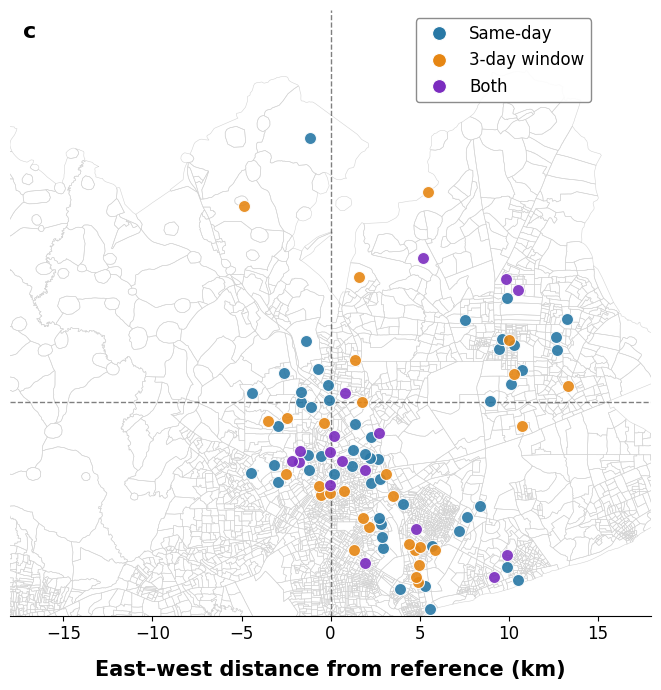

In [25]:
fig, ax, temperature_ea_centroids = (
    plot_ea_risk_distances(
        gdf=merged_risk_gdf,
        base_gdf=filt_all_eas_dem_df_filt,

        # Select one event
        event_filter=None,
        # event_filter='T',

        # Reference based on the full basemap
        use_union_centroid=True,
        use_km=True,
        x_ref_offset=common_x_ref_offset,
        y_ref_offset=common_y_ref_offset,

        # Show full EA basemap
        show_basemap=True,
        basemap_facecolor="none",
        basemap_edgecolor="lightgrey",
        basemap_linewidth=0.4,
        basemap_alpha=1.0,

        # Risk styling
        one_day_color="#2878A5",
        three_day_color="#E68613",
        both_color="#7B2CBF",

        point_size=75,
        point_alpha=0.9,
        point_edgecolor="white",
        point_linewidth=0.8,

        # Axes
        show_yaxis=False,
        # figsize=fig_size,
        figsize=(9,7),


        # Common limits across plots
        xlim=common_xlim,
        ylim=common_ylim,

        # Panel label
        panel_label="c",
        panel_label_x=0.02,
        panel_label_y=0.98,

        # Legend
        legend_loc="upper left",
        legend_bbox=(0.62, 1.00),
        legend_frame=True,

        diagnostics=True,

        # Save figure
        save_path=PLOTS_DIR / "all_event_site_1_3_day_outage_odds.png",
        dpi=300
    )
)

In [26]:
merged_risk_gdf[merged_risk_gdf['event'] == 'T']['one_day_risk'].sum()

np.int64(19)

In [27]:
merged_risk_gdf[merged_risk_gdf['event'] == 'T']['three_day_risk'].sum()

np.int64(14)

In [28]:
merged_risk_gdf[merged_risk_gdf['event'] == 'T']['both'].sum()

np.int64(6)

### EAs with increased outage odds during E.W 

In [29]:
eas_to_plot = filt_all_eas_dem_df_filt[['ea_code9ch', 'DIST_NAME', 'geometry', 'Pcode']].merge(eas_n_cesi_level, on = 'ea_code9ch', how = 'right').drop_duplicates(subset=['ea_code9ch']).reset_index(drop=True)

In [30]:
eas_to_plot

,ea_code9ch,DIST_NAME,geometry,Pcode,cesi_level
0,30200002,GA WEST,"POLYGON ((799017.814 623458.371, 799051.565 62...",03,Low
1,30200012,GA WEST,"POLYGON ((799328.799 623914.862, 799292 623916...",03,Low
2,30200013,GA WEST,"POLYGON ((799909.133 624452.948, 799919.44 624...",03,Low
3,30200014,GA WEST,"POLYGON ((800503.736 624455.809, 800569.516 62...",03,Low
4,30200015,GA WEST,"POLYGON ((799640.296 624891.197, 799654.316 62...",03,Low
...,...,...,...,...,...
209,31300291,LA NKWANANANG MADINA,"POLYGON ((813765.805 629305.242, 813853.337 62...",03,High
210,31300310,LA NKWANANANG MADINA,"POLYGON ((811832.487 629333.217, 811643.775 62...",03,Low
211,31300328,LA NKWANANANG MADINA,"POLYGON ((813036.279 631092.941, 813016.813 63...",03,Low
212,31300407,LA NKWANANANG MADINA,"POLYGON ((811220.071 632428, 811219.23 632385....",03,Low


In [31]:
increased_outage_odds_low_CESI = [30200067,
 30200109,
 30200134,
 30200153,
 30200198,
 30200207,
 30200266,
 30200273,
 30200275,
 30200283,
 30200292,
 30200295,
 30200299,
 30200397,
 30300002,
 30300068,
 30300069,
 30300123,
 30300396,
 30403015,
 30404053,
 30406001,
 30406057,
 30406139,
 30408058,
 30408062,
 30408101,
 30408124,
 30410044,
 30410046,
 30410121,
 30410197,
 30411066,
 30411069,
 30500065,
 30500074,
 30500085,
 30500167,
 30500175,
 30500185,
 31100027,
 31100210,
 31100216,
 31100223,
 31200008,
 31200045,
 31200076,
 31200113,
 31200166,
 31300178,
 31300310]

In [32]:
increased_outage_odds_high_CESI = [30200065,
 30200075,
 30200076,
 30200092,
 30200098,
 30200126,
 30402283,
 30403138,
 30407042,
 30407084,
 30410135,
 30410146,
 30410175,
 30410186,
 30410194,
 31300205,
 31300237,
 31300267]

In [33]:
# Ensure consistent EA-code types
high_cesi_eas = {str(x) for x in increased_outage_odds_high_CESI}
low_cesi_eas = {str(x) for x in increased_outage_odds_low_CESI}

base = filt_all_eas_dem_df_filt.copy()
eas_interest = eas_to_plot.copy()

base["ea_code9ch"] = base["ea_code9ch"].astype(str)
eas_interest["ea_code9ch"] = eas_interest["ea_code9ch"].astype(str)

# Separate plotting groups
high_cesi_interest = eas_interest[
    eas_interest["ea_code9ch"].isin(high_cesi_eas)
]

low_cesi_interest = eas_interest[
    eas_interest["ea_code9ch"].isin(low_cesi_eas)
]

other_interest = eas_interest[
    ~eas_interest["ea_code9ch"].isin(high_cesi_eas | low_cesi_eas)
]

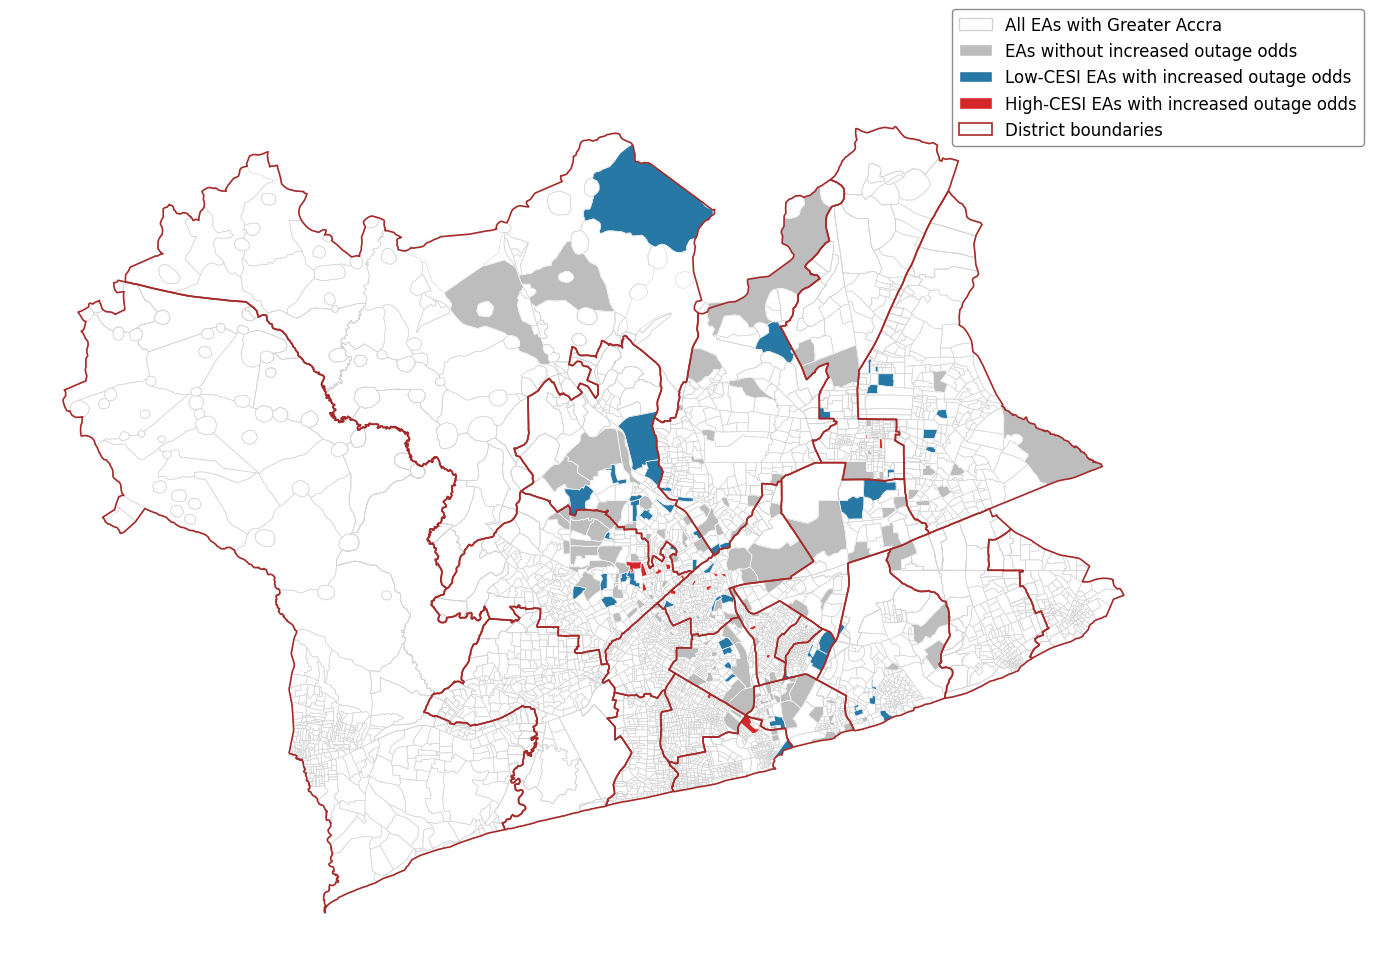

All EAs of interest: 214
Other EAs of interest: 145
Low-CESI increased-odds EAs: 51
High-CESI increased-odds EAs: 18


In [34]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14, 12))

# All EAs
base.plot(
    ax=ax,
    facecolor="none",
    edgecolor="lightgrey",
    linewidth=0.4,
    zorder=1
)

# Other EAs of interest
other_interest.plot(
    ax=ax,
    facecolor="#BDBDBD",
    edgecolor="white",
    linewidth=0.5,
    zorder=2
)

# Low-CESI EAs with increased outage odds
low_cesi_interest.plot(
    ax=ax,
    facecolor="#2878A5",
    edgecolor="white",
    linewidth=0.5,
    zorder=3
)

# High-CESI EAs with increased outage odds
high_cesi_interest.plot(
    ax=ax,
    facecolor="#D62728",
    edgecolor="white",
    linewidth=0.5,
    zorder=3
)

# District boundaries
district_gdf.to_crs(base.crs).plot(
    ax=ax,
    facecolor="none",
    edgecolor="brown",
    linewidth=1.2,
    zorder=4
)

legend_handles = [
    Patch(
        facecolor="none",
        edgecolor="lightgrey",
        label="All EAs with Greater Accra"
    ),
    Patch(
        facecolor="#BDBDBD",
        edgecolor="white",
        label="EAs without increased outage odds"
    ),
    Patch(
        facecolor="#2878A5",
        edgecolor="white",
        label="Low-CESI EAs with increased outage odds"
    ),
    Patch(
        facecolor="#D62728",
        edgecolor="white",
        label="High-CESI EAs with increased outage odds"
    ),
    Patch(
        facecolor="none",
        edgecolor="brown",
        linewidth=1.2,
        label="District boundaries"
    )
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(0.80, 1.10),
    frameon=True,
    facecolor="white",
    edgecolor="grey",
    framealpha=0.9,
    fontsize=12
)


ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"All EAs of interest: {len(eas_interest):,}")
print(f"Other EAs of interest: {len(other_interest):,}")
print(f"Low-CESI increased-odds EAs: {len(low_cesi_interest):,}")
print(f"High-CESI increased-odds EAs: {len(high_cesi_interest):,}")

### Plot same-day elevated risk EAs --> Temp 

In [35]:
# import matplotlib.pyplot as plt
# from matplotlib.patches import Patch

# fig, ax = plt.subplots(figsize=(14, 12))

# # All EAs
# base.plot(
#     ax=ax,
#     facecolor="none",
#     edgecolor="white",
#     linewidth=0.4,
#     zorder=1
# )

# # Other EAs of interest
# other_interest.plot(
#     ax=ax,
#     facecolor="#BDBDBD",
#     edgecolor="white",
#     linewidth=0.5,
#     zorder=2
# )

# # # Low-CESI EAs with increased outage odds
# # low_cesi_interest.plot(
# #     ax=ax,
# #     facecolor="#2878A5",
# #     edgecolor="white",
# #     linewidth=0.5,
# #     zorder=3
# # )

# # # High-CESI EAs with increased outage odds
# # high_cesi_interest.plot(
# #     ax=ax,
# #     facecolor="#D62728",
# #     edgecolor="white",
# #     linewidth=0.5,
# #     zorder=3
# # )

# # District boundaries
# district_gdf.to_crs(base.crs).plot(
#     ax=ax,
#     facecolor="none",
#     edgecolor="brown",
#     linewidth=1.2,
#     zorder=4
# )

# legend_handles = [
#     Patch(
#         facecolor="none",
#         edgecolor="lightgrey",
#         label="All EAs with Greater Accra"
#     ),
#     Patch(
#         facecolor="#BDBDBD",
#         edgecolor="white",
#         label="EAs"
#     ),
#     Patch(
#         facecolor="none",
#         edgecolor="brown",
#         linewidth=1.2,
#         label="District boundaries"
#     )
# ]

# ax.legend(
#     handles=legend_handles,
#     loc="upper left",
#     bbox_to_anchor=(0.80, 1.10),
#     frameon=True,
#     facecolor="white",
#     edgecolor="grey",
#     framealpha=0.9,
#     fontsize=12
# )


# ax.set_axis_off()
# plt.tight_layout()
# plt.show()

### Plot as centroids 

In [36]:
def plot_cesi_outage_risk_centroids(
    base_gdf,
    eas_interest_gdf,
    high_cesi_eas,
    low_cesi_eas,
    district_gdf=None,
    ea_col="ea_code9ch",

    # Which groups to display
    show_other_eas=False,

    # Figure
    figsize=(14, 12),

    # Point sizes
    other_point_size=65,
    low_point_size=75,
    high_point_size=75,

    # Point colors
    other_color="#BDBDBD",
    low_cesi_color="#2878A5",
    high_cesi_color="#D62728",

    # Point styling
    point_marker="o",
    point_edgecolor="white",
    point_linewidth=0.8,
    point_alpha=0.95,

    # EA basemap styling
    basemap_facecolor="none",
    basemap_edgecolor="lightgrey",
    basemap_linewidth=0.4,
    basemap_alpha=1.0,

    # District styling
    show_districts=True,
    district_facecolor="none",
    district_edgecolor="brown",
    district_linewidth=1.2,
    district_alpha=1.0,

    # Legend labels
    basemap_legend_label="All EAs within Greater Accra",
    other_legend_label="EAs without increased outage odds",
    low_legend_label=(
        "Low-CESI EAs with increased outage odds"
    ),
    high_legend_label=(
        "High-CESI EAs with increased outage odds"
    ),
    district_legend_label="District boundaries",

    # Legend position and styling
    show_legend=True,
    legend_title=None,
    legend_loc="upper left",
    legend_bbox=(0.80, 1.10),
    legend_ncol=1,
    legend_fontsize=12,
    legend_title_fontsize=12,
    legend_marker_size=9,
    legend_frame=True,
    legend_facecolor="white",
    legend_edgecolor="grey",
    legend_framealpha=0.9,

    # Plot limits
    xlim=None,
    ylim=None,

    # Title
    title=None,
    title_fontsize=16,
    title_fontweight="bold",
    title_pad=12,

    # Panel label
    panel_label=None,
    panel_label_x=0.02,
    panel_label_y=0.98,
    panel_label_fontsize=16,
    panel_label_fontweight="bold",
    panel_label_ha="left",
    panel_label_va="top",

    # Layout
    axis_off=True,
    equal_aspect=True,
    tight_layout=True,

    # Diagnostics
    print_counts=True,

    # Saving
    save_path=None,
    dpi=300,
    transparent=False,
    show=True
):
    """
    Plot centroids of low- and high-CESI EAs with increased outage
    odds over an EA polygon basemap.

    Parameters
    ----------
    base_gdf : GeoDataFrame
        Full EA polygon basemap.

    eas_interest_gdf : GeoDataFrame
        EA polygons included in the analysis.

    high_cesi_eas, low_cesi_eas : iterable
        EA codes classified as having increased outage odds.

    district_gdf : GeoDataFrame or None
        Optional district boundaries.

    show_other_eas : bool
        Whether to display centroids of analyzed EAs that are not
        included in the low- or high-CESI increased-odds groups.

    Returns
    -------
    fig, ax, centroid_groups
        centroid_groups is a dictionary containing:
        "other", "low", and "high".
    """

    import geopandas as gpd
    import matplotlib.pyplot as plt

    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    # =================================================
    # Validate and prepare GeoDataFrames
    # =================================================
    base = gpd.GeoDataFrame(
        base_gdf.copy(),
        geometry="geometry",
        crs=getattr(base_gdf, "crs", None)
    )

    eas_interest = gpd.GeoDataFrame(
        eas_interest_gdf.copy(),
        geometry="geometry",
        crs=getattr(eas_interest_gdf, "crs", None)
    )

    if base.crs is None:
        raise ValueError(
            "base_gdf must have a defined CRS."
        )

    if base.crs.is_geographic:
        raise ValueError(
            "base_gdf must use a projected CRS before "
            "calculating centroids. For Greater Accra, "
            "use EPSG:32630."
        )

    if eas_interest.crs is None:
        raise ValueError(
            "eas_interest_gdf must have a defined CRS."
        )

    if ea_col not in base.columns:
        raise ValueError(
            f"'{ea_col}' was not found in base_gdf."
        )

    if ea_col not in eas_interest.columns:
        raise ValueError(
            f"'{ea_col}' was not found in "
            "eas_interest_gdf."
        )

    # Match CRS
    if eas_interest.crs != base.crs:
        eas_interest = eas_interest.to_crs(
            base.crs
        )

    # Clean geometries
    base = base.dropna(
        subset=[ea_col, "geometry"]
    ).copy()

    eas_interest = eas_interest.dropna(
        subset=[ea_col, "geometry"]
    ).copy()

    base = base[
        ~base.geometry.is_empty
    ].copy()

    eas_interest = eas_interest[
        ~eas_interest.geometry.is_empty
    ].copy()

    # Standardize EA identifiers
    base[ea_col] = (
        base[ea_col]
        .astype(str)
        .str.strip()
    )

    eas_interest[ea_col] = (
        eas_interest[ea_col]
        .astype(str)
        .str.strip()
    )

    high_cesi_eas = {
        str(code).strip()
        for code in high_cesi_eas
    }

    low_cesi_eas = {
        str(code).strip()
        for code in low_cesi_eas
    }

    # Check for an EA appearing in both lists
    overlapping_eas = (
        high_cesi_eas & low_cesi_eas
    )

    if overlapping_eas:
        raise ValueError(
            "Some EA codes occur in both the high- and "
            "low-CESI lists: "
            f"{sorted(overlapping_eas)[:10]}"
        )

    # Repair invalid geometries
    base_invalid = ~base.geometry.is_valid

    if base_invalid.any():
        base.loc[
            base_invalid,
            "geometry"
        ] = (
            base.loc[
                base_invalid,
                "geometry"
            ]
            .buffer(0)
        )

    interest_invalid = (
        ~eas_interest.geometry.is_valid
    )

    if interest_invalid.any():
        eas_interest.loc[
            interest_invalid,
            "geometry"
        ] = (
            eas_interest.loc[
                interest_invalid,
                "geometry"
            ]
            .buffer(0)
        )

    # Dissolve possible duplicate polygons
    base = (
        base[[ea_col, "geometry"]]
        .dissolve(
            by=ea_col,
            as_index=False
        )
    )

    eas_interest = (
        eas_interest[[ea_col, "geometry"]]
        .dissolve(
            by=ea_col,
            as_index=False
        )
    )

    base = gpd.GeoDataFrame(
        base,
        geometry="geometry",
        crs=base_gdf.crs
    )

    eas_interest = gpd.GeoDataFrame(
        eas_interest,
        geometry="geometry",
        crs=base.crs
    )

    # =================================================
    # Divide EAs into mutually exclusive groups
    # =================================================
    high_interest = eas_interest[
        eas_interest[ea_col].isin(
            high_cesi_eas
        )
    ].copy()

    low_interest = eas_interest[
        eas_interest[ea_col].isin(
            low_cesi_eas
        )
    ].copy()

    other_interest = eas_interest[
        ~eas_interest[ea_col].isin(
            high_cesi_eas | low_cesi_eas
        )
    ].copy()

    # =================================================
    # Convert EA polygons to centroids
    # =================================================
    def polygons_to_centroids(polygons):
        centroids = polygons.copy()

        if not centroids.empty:
            centroids["geometry"] = (
                centroids.geometry.centroid
            )

        return gpd.GeoDataFrame(
            centroids,
            geometry="geometry",
            crs=base.crs
        )

    other_centroids = polygons_to_centroids(
        other_interest
    )

    low_centroids = polygons_to_centroids(
        low_interest
    )

    high_centroids = polygons_to_centroids(
        high_interest
    )

    # =================================================
    # Prepare district boundaries
    # =================================================
    districts = None

    if show_districts and district_gdf is not None:
        districts = gpd.GeoDataFrame(
            district_gdf.copy(),
            geometry="geometry",
            crs=getattr(district_gdf, "crs", None)
        )

        if districts.crs is None:
            raise ValueError(
                "district_gdf must have a defined CRS."
            )

        if districts.crs != base.crs:
            districts = districts.to_crs(
                base.crs
            )

        districts = districts.dropna(
            subset=["geometry"]
        ).copy()

        districts = districts[
            ~districts.geometry.is_empty
        ].copy()

    # =================================================
    # Create plot
    # =================================================
    fig, ax = plt.subplots(
        figsize=figsize
    )

    # EA polygon basemap
    base.plot(
        ax=ax,
        facecolor=basemap_facecolor,
        edgecolor=basemap_edgecolor,
        linewidth=basemap_linewidth,
        alpha=basemap_alpha,
        zorder=1
    )

    # Other analyzed EAs
    if show_other_eas and not other_centroids.empty:
        other_centroids.plot(
            ax=ax,
            color=other_color,
            marker=point_marker,
            markersize=other_point_size,
            edgecolor=point_edgecolor,
            linewidth=point_linewidth,
            alpha=point_alpha,
            zorder=2
        )

    # Low-CESI increased-odds EAs
    if not low_centroids.empty:
        low_centroids.plot(
            ax=ax,
            color=low_cesi_color,
            marker=point_marker,
            markersize=low_point_size,
            edgecolor=point_edgecolor,
            linewidth=point_linewidth,
            alpha=point_alpha,
            zorder=3
        )

    # High-CESI increased-odds EAs
    if not high_centroids.empty:
        high_centroids.plot(
            ax=ax,
            color=high_cesi_color,
            marker=point_marker,
            markersize=high_point_size,
            edgecolor=point_edgecolor,
            linewidth=point_linewidth,
            alpha=point_alpha,
            zorder=3
        )

    # District boundaries
    if districts is not None and not districts.empty:
        districts.plot(
            ax=ax,
            facecolor=district_facecolor,
            edgecolor=district_edgecolor,
            linewidth=district_linewidth,
            alpha=district_alpha,
            zorder=4
        )

    # =================================================
    # Limits and axes
    # =================================================
    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    if equal_aspect:
        ax.set_aspect(
            "equal",
            adjustable="box"
        )

    if axis_off:
        ax.set_axis_off()

    # =================================================
    # Title and panel label
    # =================================================
    if title is not None:
        ax.set_title(
            title,
            fontsize=title_fontsize,
            fontweight=title_fontweight,
            pad=title_pad
        )

    if panel_label is not None:
        ax.text(
            panel_label_x,
            panel_label_y,
            str(panel_label),
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            ha=panel_label_ha,
            va=panel_label_va,
            clip_on=False,
            zorder=10
        )

    # =================================================
    # Legend
    # =================================================

    # Legend styling
    basemap_legend_linewidth=1.5

    if show_legend:
        legend_handles = [
            Patch(
                facecolor=basemap_facecolor,
                edgecolor=basemap_edgecolor,
                linewidth=basemap_legend_linewidth,
                label=basemap_legend_label
            )
        ]

        if show_other_eas:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    marker=point_marker,
                    linestyle="none",
                    markerfacecolor=other_color,
                    markeredgecolor=point_edgecolor,
                    markeredgewidth=point_linewidth,
                    markersize=legend_marker_size,
                    label=other_legend_label
                )
            )

        legend_handles.extend([
            Line2D(
                [0],
                [0],
                marker=point_marker,
                linestyle="none",
                markerfacecolor=low_cesi_color,
                markeredgecolor=point_edgecolor,
                markeredgewidth=point_linewidth,
                markersize=legend_marker_size,
                label=low_legend_label
            ),
            Line2D(
                [0],
                [0],
                marker=point_marker,
                linestyle="none",
                markerfacecolor=high_cesi_color,
                markeredgecolor=point_edgecolor,
                markeredgewidth=point_linewidth,
                markersize=legend_marker_size,
                label=high_legend_label
            )
        ])

        if districts is not None:
            legend_handles.append(
                Patch(
                    facecolor=district_facecolor,
                    edgecolor=district_edgecolor,
                    linewidth=district_linewidth,
                    label=district_legend_label
                )
            )

        ax.legend(
            handles=legend_handles,
            title=legend_title,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox,
            ncol=legend_ncol,
            frameon=legend_frame,
            facecolor=legend_facecolor,
            edgecolor=legend_edgecolor,
            framealpha=legend_framealpha,
            fontsize=legend_fontsize,
            title_fontsize=legend_title_fontsize
        )

    # =================================================
    # Counts
    # =================================================
    if print_counts:
        print(
            f"All EAs of interest: "
            f"{eas_interest[ea_col].nunique():,}"
        )

        print(
            f"Other EAs of interest: "
            f"{other_centroids[ea_col].nunique():,}"
        )

        print(
            f"Low-CESI increased-odds EAs: "
            f"{low_centroids[ea_col].nunique():,}"
        )

        print(
            f"High-CESI increased-odds EAs: "
            f"{high_centroids[ea_col].nunique():,}"
        )

    if tight_layout:
        plt.tight_layout()

    # Save before plt.show()
    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
            transparent=transparent
        )

    if show:
        plt.show()

    centroid_groups = {
        "other": other_centroids,
        "low": low_centroids,
        "high": high_centroids
    }

    return fig, ax, centroid_groups

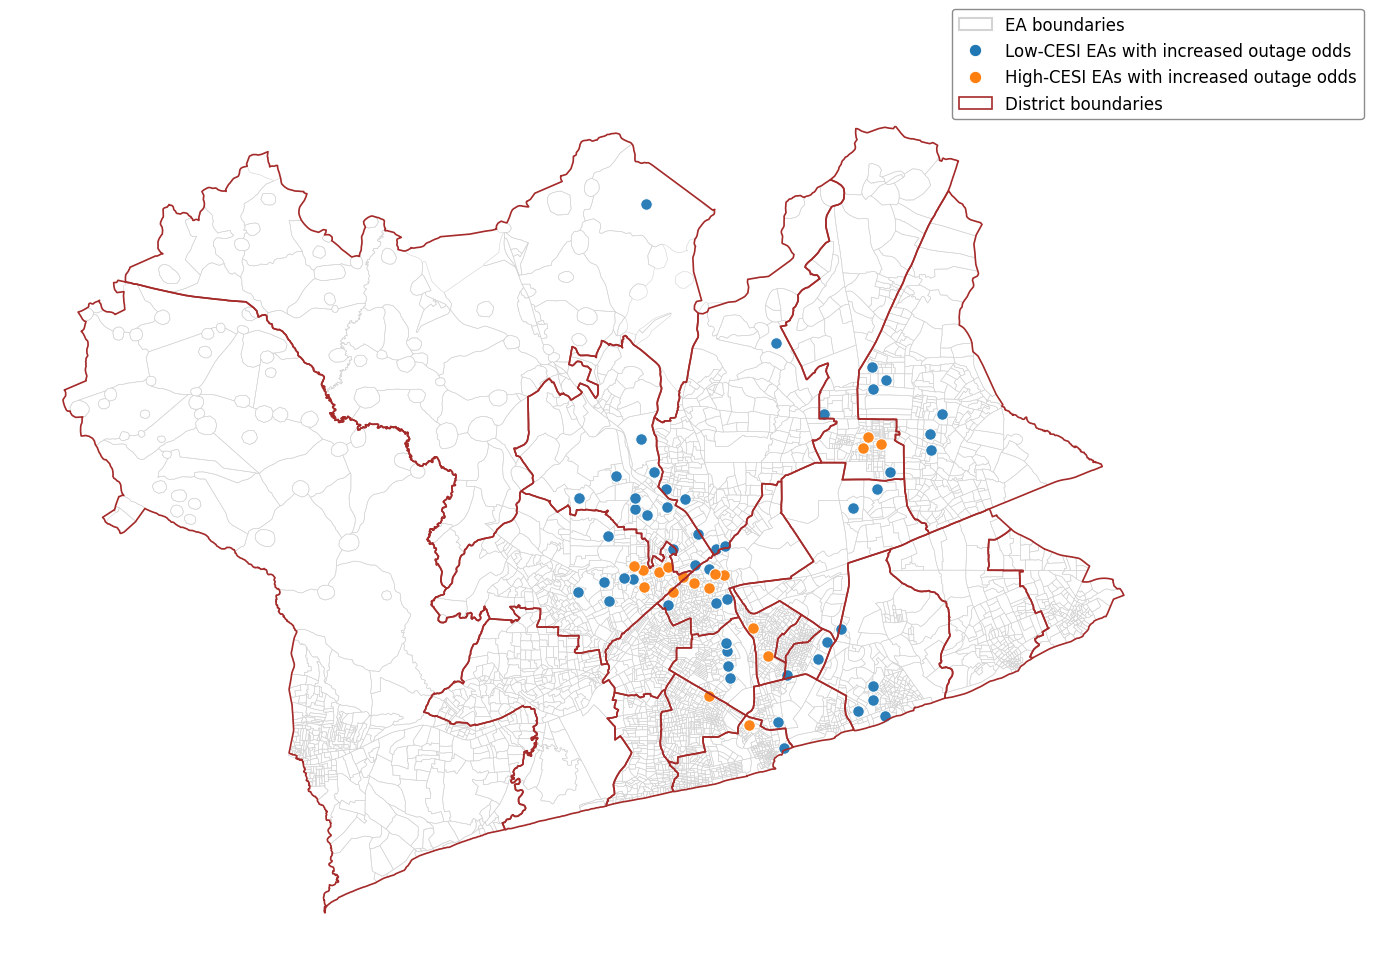

In [37]:
fig, ax, centroid_groups = (
    plot_cesi_outage_risk_centroids(
        base_gdf=filt_all_eas_dem_df_filt,
        eas_interest_gdf=eas_to_plot,

        high_cesi_eas=(
            increased_outage_odds_high_CESI
        ),
        low_cesi_eas=(
            increased_outage_odds_low_CESI
        ),

        district_gdf=district_gdf,

        # Hide EAs without increased odds
        show_other_eas=False,

        # Figure
        figsize=(14, 12),

        # Point sizes
        low_point_size=70,
        high_point_size=70,

        # CESI colors
        low_cesi_color="#1F77B4",
        high_cesi_color="#FF7F0E",

        # Point styling
        point_edgecolor="white",
        point_linewidth=0.8,
        point_alpha=0.95,

        # Basemap
        basemap_facecolor="none",
        basemap_edgecolor="lightgrey",
        basemap_linewidth=0.4,

        # Districts
        show_districts=True,
        district_edgecolor="brown",
        district_linewidth=1.2,

        # Legend labels
        basemap_legend_label=(
            "EA boundaries"
        ),
        low_legend_label=(
            "Low-CESI EAs with increased outage odds"
        ),
        high_legend_label=(
            "High-CESI EAs with increased outage odds"
        ),
        district_legend_label=(
            "District boundaries"
        ),

        # Legend position
        legend_loc="upper left",
        legend_bbox=(0.80, 1.10),
        legend_fontsize=12,
        legend_frame=True,

        # Optional panel label
        panel_label=None,

        # Output
        save_path=(
            "../outputs/plots/"
            "cesi_increased_outage_odds_centroids.png"
        ),
        dpi=300, 
        print_counts=False
    )
)

In [38]:
new_ea_copy = new_ea.copy()[['ea_code9ch', 'BASE_NAM', 'LOC_NAME']]

In [39]:
new_ea_copy

,ea_code9ch,BASE_NAM,LOC_NAME
0,30500001,MERIDIAN STORE,TESA
1,30500002,ROGER BARBERING SHOP,TESA
2,30500003,MOTORWAY DAM,TESA
3,30500004,HSE # 18 ( OPPOSITE THE MAST),TESA
4,30500008,THE ANOINTED CHURCH,TESA / ADGIRIGANO
...,...,...,...
5014,31100511,GRAND PROVIDER GLOBAL SCHOOL,ANYAA
5015,31100560,ABLEKUMA: LIBERTY ACADEMY,ABLEKUMA
5016,31400041,CHURCH OF PENTECOST,KAKASUNANKA II
5017,30802130,DIVINE TOUCH CRECHE,TEMA COMMUNITY ONE


In [40]:
eas_to_plot = eas_to_plot.merge(new_ea_copy, on = 'ea_code9ch', how = 'inner')

### *** Inspecting the high-CESI clustered EAs 

In [41]:
high_cesi_eas_w_weather = eas_to_plot[eas_to_plot['ea_code9ch'].isin(increased_outage_odds_high_CESI)].reset_index(drop=True)

In [42]:
high_cesi_eas_w_weather = high_cesi_eas_w_weather.copy()

# Calculate polygon centroids
centroids = high_cesi_eas_w_weather.geometry.centroid

high_cesi_eas_w_weather["centroid_x"] = centroids.x
high_cesi_eas_w_weather["centroid_y"] = centroids.y

In [43]:
high_cesi_eas_w_weather

,ea_code9ch,DIST_NAME,geometry,Pcode,cesi_level,BASE_NAM,LOC_NAME,centroid_x,centroid_y
0,30200065,GA WEST,"POLYGON ((802936.258 621311.052, 802943.18 621...",03,High,TABORA: GOD'S GRACE ACADEMY,TABORA,802920.021797,621121.373457
1,30200075,GA WEST,"POLYGON ((802762.737 622271.414, 802772.154 62...",03,High,TABORA: ANKOFA ENGINEERING WORKS,TABORA,802878.027511,621948.200687
2,30200076,GA WEST,"POLYGON ((802213.069 622014.405, 802215.029 62...",03,High,TABORA: VICTORY WAY CHAPEL,TABORA,802424.277329,622179.137507
3,30200092,GA WEST,"POLYGON ((803761 621988.013, 803772.049 621983...",03,High,CHANTAN: FOUNTAIN OF FAITH MINISTRIES,CHANTAN,803618.529429,621887.891858
4,30200098,GA WEST,"POLYGON ((803962.527 622254.135, 804013.085 62...",03,High,CHANTAN: LYDIA SACKEY MEMORIAL ENTERPRISE,CHANTAN,804087.927903,622134.470546
5,30200126,GA WEST,"POLYGON ((804778.425 621723.097, 804804.652 62...",03,High,NII BOI TOWN: JONO ENTERPRISE,NII BOI TOWN,804793.026348,621616.672822
6,30402283,AMA-ABLEKUMA CENTRAL,"POLYGON ((806075.777 615669.44, 806048.853 615...",03,High,TAKORADI/CAPE COAST LORRY STATION,MATAHEKO,806067.964910,615865.188180
7,30403138,AMA-ASHIEDU KETEKE,"POLYGON ((808213.142 614015.974, 808194.465 61...",03,High,31ST_DECEMBER_MARKET,KORLE DUDOR,808017.523588,614435.677095
8,30407042,AMA-AYAWASO CENTRAL,"POLYGON ((808858.224 617848.034, 808911.314 61...",03,High,GROOVY PUB,NEW TOWN,808948.504205,617778.573133
9,30407084,AMA-AYAWASO CENTRAL,"POLYGON ((808347.896 619284.124, 808348.121 61...",03,High,MANDELA SPOT,ALAJO,808211.028531,619165.978235


In [44]:
filtered_gdf = high_cesi_eas_w_weather.loc[
    (high_cesi_eas_w_weather["centroid_y"] >= 620800)
    & (high_cesi_eas_w_weather["centroid_x"] <= 812000)
].copy().reset_index(drop=True)

In [45]:
filtered_gdf

,ea_code9ch,DIST_NAME,geometry,Pcode,cesi_level,BASE_NAM,LOC_NAME,centroid_x,centroid_y
0,30200065,GA WEST,"POLYGON ((802936.258 621311.052, 802943.18 621...",03,High,TABORA: GOD'S GRACE ACADEMY,TABORA,802920.021797,621121.373457
1,30200075,GA WEST,"POLYGON ((802762.737 622271.414, 802772.154 62...",03,High,TABORA: ANKOFA ENGINEERING WORKS,TABORA,802878.027511,621948.200687
2,30200076,GA WEST,"POLYGON ((802213.069 622014.405, 802215.029 62...",03,High,TABORA: VICTORY WAY CHAPEL,TABORA,802424.277329,622179.137507
3,30200092,GA WEST,"POLYGON ((803761 621988.013, 803772.049 621983...",03,High,CHANTAN: FOUNTAIN OF FAITH MINISTRIES,CHANTAN,803618.529429,621887.891858
4,30200098,GA WEST,"POLYGON ((803962.527 622254.135, 804013.085 62...",03,High,CHANTAN: LYDIA SACKEY MEMORIAL ENTERPRISE,CHANTAN,804087.927903,622134.470546
5,30200126,GA WEST,"POLYGON ((804778.425 621723.097, 804804.652 62...",03,High,NII BOI TOWN: JONO ENTERPRISE,NII BOI TOWN,804793.026348,621616.672822
6,30410135,AMA-OKAIKOI NORTH,"POLYGON ((806062.296 620993.824, 806024.886 62...",03,High,HEAVEN GATE,ACHIMOTA,806054.572869,621105.073028
7,30410146,AMA-OKAIKOI NORTH,"POLYGON ((806749.31 621682.676, 806731.41 6216...",03,High,EPP BOOKSHOP,ACHIMOTA,806802.920019,621722.231078
8,30410175,AMA-OKAIKOI NORTH,"POLYGON ((804468.932 620897, 804463.362 620882...",03,High,COSMOS PREP. SCH. DEPT.,NII BOI TOWN,804321.639797,620893.993474
9,30410186,AMA-OKAIKOI NORTH,"POLYGON ((805202.521 621185.763, 805190.784 62...",03,High,DON-MI YORK'S NEST,ACHIMOTA,805330.032143,621335.185596


### Clustering distance 

In [46]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


def summarize_spatial_concentration(
    gdf,
    candidate_radii_km=(5, 6, 8),
    center_method="union_centroid",
    plot=True,
    figsize=(9, 9)
):

    data = gdf.copy()

    if data.crs is None:
        raise ValueError("The GeoDataFrame must have a defined CRS.")

    if data.crs.is_geographic:
        raise ValueError(
            "The GeoDataFrame must use a projected CRS measured in "
            "meters before distances are calculated."
        )

    data = data.loc[
        data.geometry.notna()
        & ~data.geometry.is_empty
    ].copy()

    # Calculate one centroid for every EA polygon
    centroid_geometry = data.geometry.centroid

    data["centroid_x"] = centroid_geometry.x
    data["centroid_y"] = centroid_geometry.y

    # Define the spatial center
    if center_method == "union_centroid":
        try:
            union_geometry = data.geometry.union_all()
        except Exception:
            union_geometry = data.geometry.unary_union

        center = union_geometry.centroid

    elif center_method == "mean_centroid":
        from shapely.geometry import Point

        center = Point(
            data["centroid_x"].mean(),
            data["centroid_y"].mean()
        )

    else:
        raise ValueError(
            "center_method must be either 'union_centroid' "
            "or 'mean_centroid'."
        )

    # Distance between every EA centroid and the common center
    data["distance_from_center_km"] = (
        centroid_geometry.distance(center) / 1000
    )

    # Coverage at each candidate radius
    coverage_records = []

    for radius_km in candidate_radii_km:
        within_radius = (
            data["distance_from_center_km"] <= radius_km
        )

        count = int(within_radius.sum())
        total = len(data)

        coverage_records.append({
            "radius_km": radius_km,
            "number_of_eas": count,
            "total_eas": total,
            "coverage_percent": 100 * count / total,
            "captures_all": count == total
        })

    coverage_df = pd.DataFrame(coverage_records)

    # Distance summary
    distance_summary = pd.Series({
        "number_of_eas": len(data),
        "median_radius_km": (
            data["distance_from_center_km"].median()
        ),
        "90_percent_radius_km": (
            data["distance_from_center_km"].quantile(0.90)
        ),
        "95_percent_radius_km": (
            data["distance_from_center_km"].quantile(0.95)
        ),
        "minimum_radius_for_all_km": (
            data["distance_from_center_km"].max()
        )
    })

    print("Center method:")
    print(center_method)

    print("\nCenter coordinates:")
    print(f"x = {center.x:.2f}")
    print(f"y = {center.y:.2f}")

    print("\nRadius coverage:")
    print(
        coverage_df.to_string(
            index=False,
            formatters={
                "coverage_percent": lambda value: f"{value:.1f}%"
            }
        )
    )

    print("\nDistance summary:")
    print(distance_summary.round(2))

    # Optional plot
    if plot:
        fig, ax = plt.subplots(figsize=figsize)

        data.plot(
            ax=ax,
            facecolor="none",
            edgecolor="lightgrey",
            linewidth=0.8,
            zorder=1
        )

        ax.scatter(
            data["centroid_x"],
            data["centroid_y"],
            s=50,
            color="tab:orange",
            edgecolor="white",
            linewidth=0.7,
            label="EA centroids",
            zorder=3
        )

        ax.scatter(
            center.x,
            center.y,
            s=140,
            color="black",
            marker="X",
            label="Spatial center",
            zorder=5
        )

        radius_colors = [
            "tab:blue",
            "tab:green",
            "tab:red",
            "tab:purple"
        ]

        for index, radius_km in enumerate(
            candidate_radii_km
        ):
            buffer_geometry = center.buffer(
                radius_km * 1000
            )

            buffer_gdf = gpd.GeoSeries(
                [buffer_geometry],
                crs=data.crs
            )

            buffer_gdf.boundary.plot(
                ax=ax,
                color=radius_colors[
                    index % len(radius_colors)
                ],
                linewidth=1.5,
                linestyle="--",
                label=f"{radius_km} km radius",
                zorder=2
            )

        ax.set_aspect("equal")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        ax.legend()

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()
        plt.show()

    return data, coverage_df, center, distance_summary

Center method:
mean_centroid

Center coordinates:
x = 804508.27
y = 621609.00

Radius coverage:
 radius_km  number_of_eas  total_eas coverage_percent  captures_all
         1              5         11            45.5%         False
         2              9         11            81.8%         False
         3             11         11           100.0%          True
         4             11         11           100.0%          True
         5             11         11           100.0%          True

Distance summary:
number_of_eas                11.00
median_radius_km              1.63
90_percent_radius_km          2.16
95_percent_radius_km          2.23
minimum_radius_for_all_km     2.30
dtype: float64


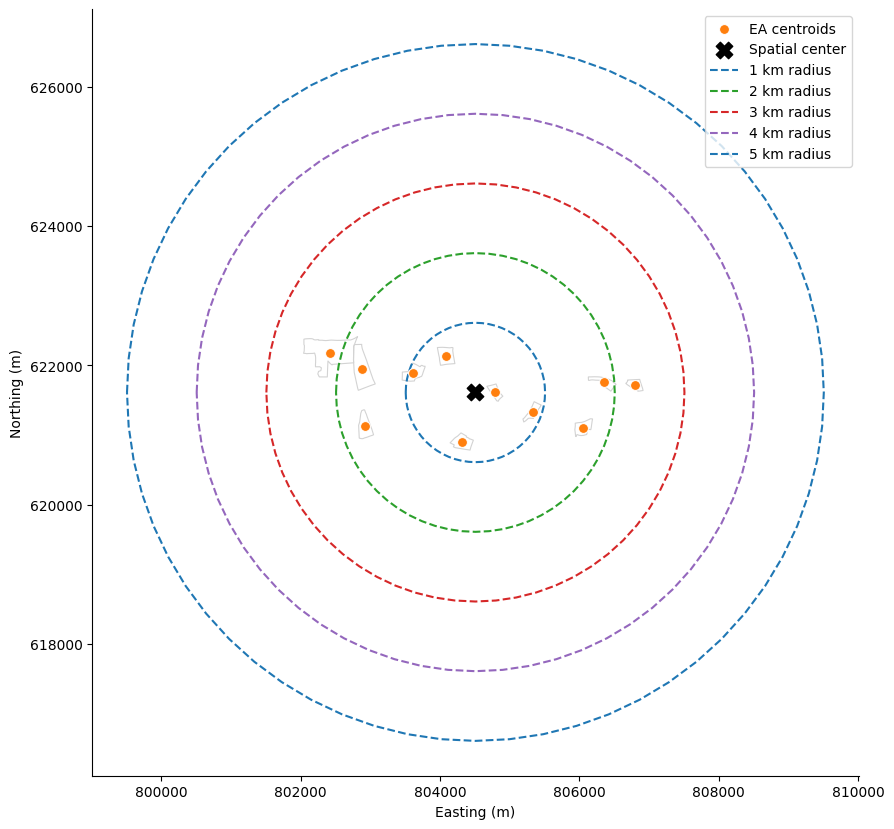

In [47]:
(
    high_cesi_distance_gdf,
    radius_coverage_df,
    high_cesi_center,
    high_cesi_distance_summary
) = summarize_spatial_concentration(
    gdf=filtered_gdf,
    candidate_radii_km=(1,2,3,4,5),
    center_method="mean_centroid",
    plot=True
)

### Read the same-day source file

In [48]:
same_day_summary_df = pd.read_csv(DATA_DIR / 'miscellaneous/summary_df_same_day_rev1.csv').drop(columns = ['Unnamed: 0'])

In [49]:
same_day_summary_df['ea_code9ch'] = same_day_summary_df['ea_code9ch'].astype('int64')
eas_n_cesi_level['ea_code9ch'] = eas_n_cesi_level['ea_code9ch'].astype('int64')

same_day_summary_df = same_day_summary_df.merge(
    eas_n_cesi_level,
    on='ea_code9ch'
)

In [50]:
same_day_summary_df

,ea_code9ch,event,odds_ratio,cesi_level
0,30200065,T,3.96,High
1,30200067,T,3.31,Low
2,30200075,T,2.21,High
3,30200076,T,4.23,High
4,30200092,T,3.09,High
...,...,...,...,...
69,31300178,P,3.15,Low
70,31300205,L,9.31,High
71,31300237,L,6.00,High
72,31300267,P,3.36,High


In [51]:
common_x_ref_offset = 4     # km east if use_km=True
common_y_ref_offset = -1 

fig_size=(10, 8)

common_xlim = (-18, 18)
common_ylim = (-12, 22)

### Visualize -- plot the centroids 

In [52]:
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from shapely import affinity


def plot_same_day_outage_risk_relative(
    base_gdf,
    summary_df,
    event="T",
    ea_col="ea_code9ch",
    event_col="event",
    cesi_col="cesi_level",

    # Reference point
    use_union_centroid=True,
    ref_easting=None,
    ref_northing=None,
    x_ref_offset=0,
    y_ref_offset=0,
    use_km=True,

    # Background EA map
    show_basemap=False,
    basemap_facecolor="none",
    basemap_edgecolor="lightgrey",
    basemap_linewidth=0.4,
    basemap_alpha=1.0,

    # Centroid styling
    point_size=80,
    point_edgecolor="white",
    point_linewidth=0.8,
    point_marker="o",
    point_alpha=1.0,

    # Reference lines
    show_reference_lines=True,
    reference_linecolor="black",
    reference_linestyle="--",
    reference_linewidth=1,
    reference_alpha=0.5,

    # Reference point marker
    show_reference_point=False,
    reference_point_size=80,
    reference_point_marker="X",
    reference_point_color="black",

    # Figure and axes
    figsize=(10, 8),
    xlim=None,
    ylim=None,
    show_yaxis=True,

    # Axis labels
    x_label=None,
    y_label=None,
    axis_label_fontsize=15,
    axis_label_fontweight="bold",
    axis_labelpad=12,

    # Tick labels
    x_tick_fontsize=12,
    y_tick_fontsize=12,
    x_rotation=0,

    # Same colors as histogram
    cesi_colors={
        "Low": "tab:blue",
        "High": "tab:orange"
    },
    cesi_order=("Low", "High"),
    cesi_legend_labels={
        "Low": "Low CESI",
        "High": "High CESI"
    },

    # Panel label using ax.transAxes
    panel_label=None,
    panel_label_x=0.02,
    panel_label_y=0.98,
    panel_label_fontsize=16,
    panel_label_fontweight="bold",
    panel_label_ha="left",
    panel_label_va="top",

    # Legend
    show_legend=True,
    legend_title=None,
    legend_title_fontsize=12,
    legend_loc="upper left",
    legend_bbox=(0.60, 1.10),
    legend_fontsize=12,
    legend_marker_size=10,
    legend_frame=True,
    legend_facecolor="white",
    legend_edgecolor="grey",
    legend_framealpha=0.9,

    # Optional title
    title=None,
    title_fontsize=16,
    title_fontweight="bold",
    title_pad=15,

    # Output
    print_count=True,
    save_path=None,
    dpi=300
):
    """
    Plot centroids of EAs with increased same-day outage risk for a
    selected weather event.

    Locations are expressed as east-west and north-south distances
    from a common reference point. Centroid colors indicate CESI level.

    Duplicate EA polygon rows in base_gdf are dissolved so that each
    EA has one geometry and one centroid.
    """

    # -------------------------------------------------
    # Default CESI styling
    # -------------------------------------------------
    if cesi_colors is None:
        cesi_colors = {
            "Low": "#2878A5",
            "High": "#D62728"
        }

    if cesi_legend_labels is None:
        cesi_legend_labels = {
            "Low": "Low CESI",
            "High": "High CESI"
        }

    # -------------------------------------------------
    # Prepare input data
    # -------------------------------------------------
    base = gpd.GeoDataFrame(
        base_gdf.copy(),
        geometry="geometry",
        crs=base_gdf.crs
    )

    results = summary_df.copy()

    # Check CRS
    if base.crs is None:
        raise ValueError(
            "base_gdf must have a defined CRS."
        )

    if base.crs.is_geographic:
        raise ValueError(
            "base_gdf must use a projected CRS before calculating "
            "centroids and distances. For Greater Accra, you can use "
            "base_gdf.to_crs(epsg=32630)."
        )

    # Check required base columns
    required_base_columns = {
        ea_col,
        "geometry"
    }

    missing_base_columns = (
        required_base_columns - set(base.columns)
    )

    if missing_base_columns:
        raise ValueError(
            f"Missing columns in base_gdf: "
            f"{sorted(missing_base_columns)}"
        )

    # Check required results columns
    required_result_columns = {
        ea_col,
        event_col,
        cesi_col
    }

    missing_result_columns = (
        required_result_columns - set(results.columns)
    )

    if missing_result_columns:
        raise ValueError(
            f"Missing columns in summary_df: "
            f"{sorted(missing_result_columns)}"
        )

    # -------------------------------------------------
    # Clean and dissolve base geometries
    # -------------------------------------------------
    base = base.dropna(
        subset=[ea_col, "geometry"]
    ).copy()

    base = base[
        ~base.geometry.is_empty
    ].copy()

    # Standardize EA codes
    base[ea_col] = (
        base[ea_col]
        .astype(str)
        .str.strip()
    )

    # Combine duplicate polygon rows into one geometry per EA
    base = (
        base[[ea_col, "geometry"]]
        .dissolve(
            by=ea_col,
            as_index=False
        )
    )

    if not base[ea_col].is_unique:
        raise ValueError(
            "EA codes are still duplicated after dissolving."
        )

    # -------------------------------------------------
    # Clean results
    # -------------------------------------------------
    results = results.dropna(
        subset=[ea_col, event_col, cesi_col]
    ).copy()

    results[ea_col] = (
        results[ea_col]
        .astype(str)
        .str.strip()
    )

    results[event_col] = (
        results[event_col]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    results[cesi_col] = (
        results[cesi_col]
        .astype(str)
        .str.strip()
        .str.title()
    )

    event = str(event).strip().upper()

    available_events = sorted(
        results[event_col].unique()
    )

    if event not in available_events:
        raise ValueError(
            f"Event '{event}' was not found. "
            f"Available events are: {available_events}"
        )

    # -------------------------------------------------
    # Select results for requested event
    # -------------------------------------------------
    event_results = results.loc[
        results[event_col].eq(event),
        [ea_col, cesi_col]
    ].copy()

    # Check whether an EA has conflicting CESI categories
    cesi_counts_per_ea = (
        event_results
        .groupby(ea_col)[cesi_col]
        .nunique()
    )

    conflicting_eas = (
        cesi_counts_per_ea[
            cesi_counts_per_ea > 1
        ]
        .index
        .tolist()
    )

    if conflicting_eas:
        raise ValueError(
            "Some EAs have more than one CESI category: "
            f"{conflicting_eas[:10]}"
        )

    # Keep one result row per EA
    event_results = (
        event_results
        .drop_duplicates(subset=[ea_col])
        .reset_index(drop=True)
    )

    # -------------------------------------------------
    # Join CESI categories to EA geometries
    # -------------------------------------------------
    event_interest = base.merge(
        event_results,
        on=ea_col,
        how="inner",
        validate="one_to_one"
    )

    event_interest = gpd.GeoDataFrame(
        event_interest,
        geometry="geometry",
        crs=base.crs
    )

    if event_interest.empty:
        raise ValueError(
            f"No matching EA geometries were found for event "
            f"'{event}'."
        )

    # -------------------------------------------------
    # Calculate EA centroids
    # -------------------------------------------------
    event_centroids = event_interest.copy()

    event_centroids["geometry"] = (
        event_interest.geometry.centroid
    )

    event_centroids["easting"] = (
        event_centroids.geometry.x
    )

    event_centroids["northing"] = (
        event_centroids.geometry.y
    )

    # -------------------------------------------------
    # Define common reference point
    # -------------------------------------------------
    if use_union_centroid:
        try:
            base_union = base.geometry.union_all()
        except Exception:
            base_union = base.geometry.unary_union

        reference_point = base_union.centroid

        ref_easting = reference_point.x
        ref_northing = reference_point.y

    else:
        if ref_easting is None or ref_northing is None:
            raise ValueError(
                "Provide both ref_easting and ref_northing when "
                "use_union_centroid=False."
            )

    # -------------------------------------------------
    # Apply reference offsets
    # -------------------------------------------------
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000

        conversion_factor = 1000
        unit_label = "km"

    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

        conversion_factor = 1
        unit_label = "m"

    # -------------------------------------------------
    # Calculate coordinates relative to reference
    # -------------------------------------------------
    event_centroids["x_distance"] = (
        event_centroids["easting"] - ref_easting
    ) / conversion_factor

    event_centroids["y_distance"] = (
        event_centroids["northing"] - ref_northing
    ) / conversion_factor

    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    if print_count:
        print(
            f"{event} EA centroids plotted: "
            f"{event_centroids[ea_col].nunique()}"
        )

        print("\nCESI counts:")

        print(
            event_centroids[cesi_col]
            .value_counts()
            .reindex(
                cesi_order,
                fill_value=0
            )
        )

        print(
            f"\nReference offset: "
            f"x={x_ref_offset} {unit_label}, "
            f"y={y_ref_offset} {unit_label}"
        )

    # -------------------------------------------------
    # Create figure
    # -------------------------------------------------
    fig, ax = plt.subplots(
        figsize=figsize
    )

    # -------------------------------------------------
    # Optional relative-coordinate EA basemap
    # -------------------------------------------------
    if show_basemap:
        relative_base = base.copy()

        relative_base["geometry"] = (
            relative_base.geometry.apply(
                lambda geom: affinity.scale(
                    affinity.translate(
                        geom,
                        xoff=-ref_easting,
                        yoff=-ref_northing
                    ),
                    xfact=1 / conversion_factor,
                    yfact=1 / conversion_factor,
                    origin=(0, 0)
                )
            )
        )

        relative_base.plot(
            ax=ax,
            facecolor=basemap_facecolor,
            edgecolor=basemap_edgecolor,
            linewidth=basemap_linewidth,
            alpha=basemap_alpha,
            zorder=1
        )

    # -------------------------------------------------
    # Plot EA centroids by CESI category
    # -------------------------------------------------
    observed_levels = list(
        event_centroids[cesi_col]
        .dropna()
        .unique()
    )

    ordered_observed_levels = [
        level
        for level in cesi_order
        if level in observed_levels
    ]

    unexpected_levels = [
        level
        for level in observed_levels
        if level not in cesi_order
    ]

    plot_levels = (
        ordered_observed_levels
        + unexpected_levels
    )

    for cesi_level in plot_levels:
        cesi_subset = event_centroids[
            event_centroids[cesi_col].eq(
                cesi_level
            )
        ]

        ax.scatter(
            cesi_subset["x_distance"],
            cesi_subset["y_distance"],
            s=point_size,
            c=cesi_colors.get(
                cesi_level,
                "#7F7F7F"
            ),
            marker=point_marker,
            edgecolors=point_edgecolor,
            linewidths=point_linewidth,
            alpha=point_alpha,
            zorder=3
        )

    # -------------------------------------------------
    # Reference lines
    # -------------------------------------------------
    if show_reference_lines:
        ax.axhline(
            0,
            color=reference_linecolor,
            linestyle=reference_linestyle,
            linewidth=reference_linewidth,
            alpha=reference_alpha,
            zorder=2
        )

        ax.axvline(
            0,
            color=reference_linecolor,
            linestyle=reference_linestyle,
            linewidth=reference_linewidth,
            alpha=reference_alpha,
            zorder=2
        )

    # -------------------------------------------------
    # Reference point
    # -------------------------------------------------
    if show_reference_point:
        ax.scatter(
            0,
            0,
            s=reference_point_size,
            c=reference_point_color,
            marker=reference_point_marker,
            zorder=4
        )

    # -------------------------------------------------
    # Panel label using ax.transAxes
    # -------------------------------------------------
    if panel_label is not None:
        ax.text(
            panel_label_x,
            panel_label_y,
            str(panel_label),
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            horizontalalignment=panel_label_ha,
            verticalalignment=panel_label_va,
            clip_on=False,
            zorder=10
        )

    # -------------------------------------------------
    # Axis labels
    # -------------------------------------------------
    if x_label is None:
        x_label = (
            f"East–West distance from reference "
            f"({unit_label})"
        )

    if y_label is None:
        y_label = (
            f"North–South distance from reference "
            f"({unit_label})"
        )

    ax.set_xlabel(
        x_label,
        fontsize=axis_label_fontsize,
        fontweight=axis_label_fontweight,
        labelpad=axis_labelpad
    )

    ax.set_ylabel(
        y_label,
        fontsize=axis_label_fontsize,
        fontweight=axis_label_fontweight,
        labelpad=axis_labelpad
    )

    # -------------------------------------------------
    # Axis ticks
    # -------------------------------------------------
    ax.tick_params(
        axis="x",
        labelsize=x_tick_fontsize,
        labelrotation=x_rotation
    )

    ax.tick_params(
        axis="y",
        labelsize=y_tick_fontsize
    )

    # Hide y-axis if requested
    if not show_yaxis:
        ax.yaxis.set_visible(False)
        ax.spines["left"].set_visible(False)

    # Axis limits
    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    # Preserve spatial proportions
    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # -------------------------------------------------
    # CESI-only legend
    # -------------------------------------------------
    if show_legend:
        legend_handles = [
            Line2D(
                [0],
                [0],
                marker=point_marker,
                linestyle="none",
                markerfacecolor=cesi_colors.get(
                    level,
                    "#7F7F7F"
                ),
                markeredgecolor=point_edgecolor,
                markeredgewidth=point_linewidth,
                markersize=legend_marker_size,
                label=cesi_legend_labels.get(
                    level,
                    level
                )
            )
            for level in plot_levels
        ]

        ax.legend(
            handles=legend_handles,
            title=legend_title,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox,
            frameon=legend_frame,
            facecolor=legend_facecolor,
            edgecolor=legend_edgecolor,
            framealpha=legend_framealpha,
            fontsize=legend_fontsize,
            title_fontsize=legend_title_fontsize
        )

    # -------------------------------------------------
    # Optional title
    # -------------------------------------------------
    if title is not None:
        ax.set_title(
            title,
            fontsize=title_fontsize,
            fontweight=title_fontweight,
            pad=title_pad
        )

    plt.tight_layout()

    # -------------------------------------------------
    # Optional save
    # -------------------------------------------------
    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()

    return fig, ax, event_centroids

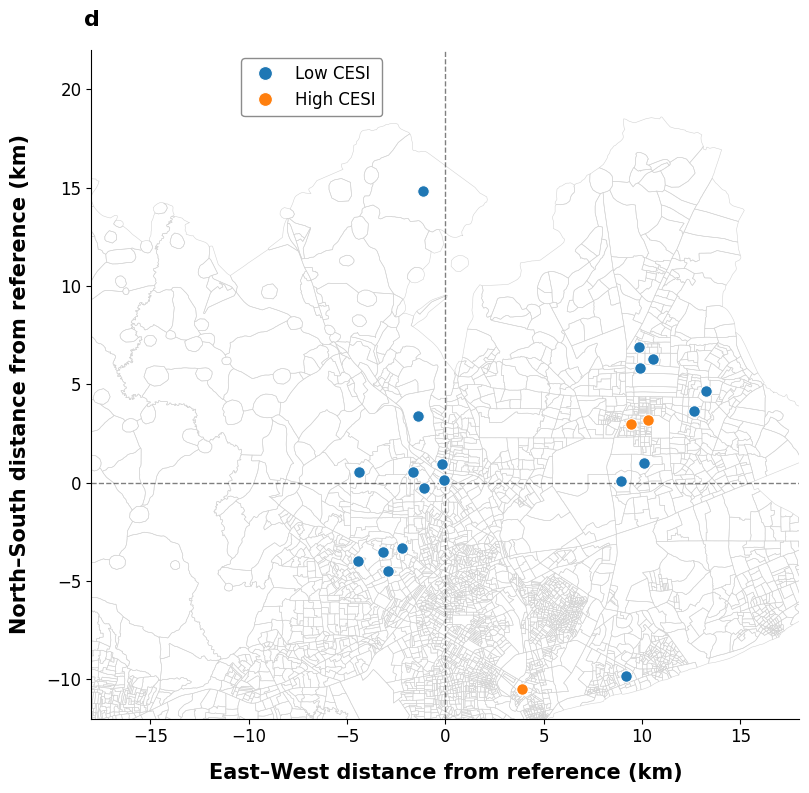

In [53]:
fig, ax, precipitation_centroids = (
    plot_same_day_outage_risk_relative(
        base_gdf=filt_all_eas_dem_df_filt,
        summary_df=same_day_summary_df,
        event="L",
        print_count=False, 

        use_union_centroid=True,
        use_km=True,
        x_ref_offset=common_x_ref_offset,
        y_ref_offset=common_y_ref_offset,

        show_yaxis=True,
        show_basemap=True,

        # CESI styling
        cesi_colors={
            "Low": "tab:blue",
            "High": "tab:orange"
        },
        cesi_order=("Low", "High"),
        cesi_legend_labels={
            "Low": "Low CESI",
            "High": "High CESI"
        },

        point_size=70,
        point_edgecolor="white",
        point_linewidth=0.8,

        # Panel label
        panel_label="d",
        panel_label_x=-0.01,
        panel_label_y=1.06,
        panel_label_fontsize=16,

        # Legend
        legend_title=None,
        legend_loc="upper left",
        legend_bbox=(0.20, 1.00),
        legend_fontsize=12,

        figsize=fig_size,
        xlim=common_xlim,
        ylim=common_ylim, 

        # Save figure
        save_path=PLOTS_DIR / "elevated_risk_by_CESI_Lightning_basemap.png",
        dpi=300
    )
)

In [54]:
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from shapely import affinity


def plot_all_same_day_outage_risk_relative(
    base_gdf,
    summary_df,

    # Columns
    ea_col="ea_code9ch",
    event_col="event",
    cesi_col="cesi_level",

    # Events and panel organization
    events=("T", "P", "W", "L"),
    event_titles=None,
    panel_labels=("a", "b", "c", "d"),

    # Reference point
    use_union_centroid=True,
    ref_easting=None,
    ref_northing=None,
    x_ref_offset=0,
    y_ref_offset=0,
    use_km=True,

    # Background EA map
    show_basemap=False,
    basemap_facecolor="none",
    basemap_edgecolor="lightgrey",
    basemap_linewidth=0.4,
    basemap_alpha=1.0,

    # Centroid styling
    point_size=80,
    point_edgecolor="white",
    point_linewidth=0.8,
    point_marker="o",
    point_alpha=1.0,

    # CESI styling
    cesi_colors=None,
    cesi_order=("Low", "High"),
    cesi_legend_labels=None,

    # Reference lines
    show_reference_lines=True,
    reference_linecolor="black",
    reference_linestyle="--",
    reference_linewidth=1,
    reference_alpha=0.5,

    # Reference point marker
    show_reference_point=False,
    reference_point_size=80,
    reference_point_marker="X",
    reference_point_color="black",

    # Figure
    figsize=(15, 13),
    sharex=True,
    sharey=True,
    xlim=None,
    ylim=None,

    # Shared axis labels
    x_label=None,
    y_label=None,
    axis_label_fontsize=15,
    axis_label_fontweight="bold",

    # Tick labels
    x_tick_fontsize=12,
    y_tick_fontsize=12,
    x_rotation=0,

    # Panel labels
    panel_label_x=-0.01,
    panel_label_y=1.06,
    panel_label_fontsize=16,
    panel_label_fontweight="bold",
    panel_label_ha="left",
    panel_label_va="top",

    # Shared axis-label positions
    x_label_x=0.5,
    x_label_y=0.025,
    y_label_x=0.025,
    y_label_y=0.5,

    # Panel titles
    show_titles=True,
    title_fontsize=15,
    title_fontweight="bold",
    title_pad=10,

    # Shared legend
    show_legend=True,
    legend_title=None,
    legend_title_fontsize=12,
    legend_loc="upper center",
    legend_bbox=(0.5, 0.985),
    legend_ncol=2,
    legend_fontsize=12,
    legend_marker_size=10,
    legend_frame=True,
    legend_facecolor="white",
    legend_edgecolor="grey",
    legend_framealpha=0.9,

    # Figure spacing
    left=0.09,
    right=0.98,
    bottom=0.08,
    top=0.90,
    wspace=0.08,
    hspace=0.16,

    # Output
    print_count=True,
    save_path=None,
    dpi=300,
    show=True
):
    """
    Plot elevated same-day outage-risk locations for four weather
    events in a 2 x 2 figure.

    Each point represents the centroid of an EA appearing in
    summary_df for the corresponding event. Point color indicates
    the EA's CESI category.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Complete figure.

    axes : numpy.ndarray
        A 2 x 2 array of matplotlib axes.

    event_centroids : dict
        Dictionary of GeoDataFrames, indexed by event code.
        For example, event_centroids["T"].
    """

    # -------------------------------------------------
    # Defaults
    # -------------------------------------------------
    if event_titles is None:
        event_titles = {
            "T": "Extreme Temperature",
            "P": "Heavy Precipitation",
            "W": "High Wind",
            "L": "Lightning"
        }

    if cesi_colors is None:
        cesi_colors = {
            "Low": "tab:blue",
            "High": "tab:orange"
        }

    if cesi_legend_labels is None:
        cesi_legend_labels = {
            "Low": "Low CESI",
            "High": "High CESI"
        }

    events = tuple(
        str(event).strip().upper()
        for event in events
    )

    if len(events) != 4:
        raise ValueError(
            "Exactly four events are required for the 2 x 2 figure."
        )

    if len(panel_labels) != len(events):
        raise ValueError(
            "panel_labels must have one label for each event."
        )

    # -------------------------------------------------
    # Prepare base GeoDataFrame
    # -------------------------------------------------
    base = gpd.GeoDataFrame(
        base_gdf.copy(),
        geometry="geometry",
        crs=base_gdf.crs
    )

    if base.crs is None:
        raise ValueError(
            "base_gdf must have a defined CRS."
        )

    if base.crs.is_geographic:
        raise ValueError(
            "base_gdf must use a projected CRS before calculating "
            "centroids and distances. For Greater Accra, use "
            "base_gdf.to_crs(epsg=32630)."
        )

    required_base_columns = {
        ea_col,
        "geometry"
    }

    missing_base_columns = (
        required_base_columns - set(base.columns)
    )

    if missing_base_columns:
        raise ValueError(
            f"Missing columns in base_gdf: "
            f"{sorted(missing_base_columns)}"
        )

    base = base.dropna(
        subset=[ea_col, "geometry"]
    ).copy()

    base = base.loc[
        ~base.geometry.is_empty
    ].copy()

    base[ea_col] = (
        base[ea_col]
        .astype(str)
        .str.strip()
    )

    # Dissolve duplicate polygon rows so each EA has one geometry
    base = (
        base[[ea_col, "geometry"]]
        .dissolve(
            by=ea_col,
            as_index=False
        )
    )

    if not base[ea_col].is_unique:
        raise ValueError(
            "EA codes are still duplicated after dissolving."
        )

    # -------------------------------------------------
    # Prepare summary data
    # -------------------------------------------------
    results = summary_df.copy()

    required_result_columns = {
        ea_col,
        event_col,
        cesi_col
    }

    missing_result_columns = (
        required_result_columns - set(results.columns)
    )

    if missing_result_columns:
        raise ValueError(
            f"Missing columns in summary_df: "
            f"{sorted(missing_result_columns)}"
        )

    results = results.dropna(
        subset=[ea_col, event_col, cesi_col]
    ).copy()

    results[ea_col] = (
        results[ea_col]
        .astype(str)
        .str.strip()
    )

    results[event_col] = (
        results[event_col]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    results[cesi_col] = (
        results[cesi_col]
        .astype(str)
        .str.strip()
        .str.title()
    )

    available_events = sorted(
        results[event_col].unique()
    )

    missing_events = [
        event
        for event in events
        if event not in available_events
    ]

    if missing_events:
        raise ValueError(
            f"Events {missing_events} were not found in summary_df. "
            f"Available events are: {available_events}"
        )

    # -------------------------------------------------
    # Check for conflicting CESI values
    # -------------------------------------------------
    selected_results = results.loc[
        results[event_col].isin(events),
        [ea_col, event_col, cesi_col]
    ].copy()

    cesi_counts = (
        selected_results
        .groupby([event_col, ea_col])[cesi_col]
        .nunique()
    )

    conflicting_pairs = (
        cesi_counts.loc[cesi_counts > 1]
        .index
        .tolist()
    )

    if conflicting_pairs:
        raise ValueError(
            "Some event-EA combinations have more than one CESI "
            f"category. Examples: {conflicting_pairs[:10]}"
        )

    # -------------------------------------------------
    # Define common reference point
    # -------------------------------------------------
    if use_union_centroid:
        try:
            base_union = base.geometry.union_all()
        except Exception:
            base_union = base.geometry.unary_union

        reference_point = base_union.centroid

        reference_easting = reference_point.x
        reference_northing = reference_point.y

    else:
        if ref_easting is None or ref_northing is None:
            raise ValueError(
                "Provide both ref_easting and ref_northing when "
                "use_union_centroid=False."
            )

        reference_easting = ref_easting
        reference_northing = ref_northing

    # -------------------------------------------------
    # Apply reference offsets and determine units
    # -------------------------------------------------
    if use_km:
        reference_easting += x_ref_offset * 1000
        reference_northing += y_ref_offset * 1000

        conversion_factor = 1000
        unit_label = "km"

    else:
        reference_easting += x_ref_offset
        reference_northing += y_ref_offset

        conversion_factor = 1
        unit_label = "m"

    if x_label is None:
        x_label = (
            f"East–West distance from reference ({unit_label})"
        )

    if y_label is None:
        y_label = (
            f"North–South distance from reference ({unit_label})"
        )

    # -------------------------------------------------
    # Transform basemap to relative coordinates once
    # -------------------------------------------------
    relative_base = None

    if show_basemap:
        relative_base = base.copy()

        relative_base["geometry"] = (
            relative_base.geometry.apply(
                lambda geometry: affinity.scale(
                    affinity.translate(
                        geometry,
                        xoff=-reference_easting,
                        yoff=-reference_northing
                    ),
                    xfact=1 / conversion_factor,
                    yfact=1 / conversion_factor,
                    origin=(0, 0)
                )
            )
        )

    # -------------------------------------------------
    # Create figure
    # -------------------------------------------------
    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=figsize,
        sharex=sharex,
        sharey=sharey
    )

    axes_flat = axes.ravel()

    event_centroids = {}
    observed_cesi_levels = set()

    # -------------------------------------------------
    # Create each event panel
    # -------------------------------------------------
    for ax, event, panel_label in zip(
        axes_flat,
        events,
        panel_labels
    ):
        # Select current event
        event_results = results.loc[
            results[event_col].eq(event),
            [ea_col, cesi_col]
        ].copy()

        event_results = (
            event_results
            .drop_duplicates(subset=[ea_col])
            .reset_index(drop=True)
        )

        # Join event results to EA geometries
        event_interest = base.merge(
            event_results,
            on=ea_col,
            how="inner",
            validate="one_to_one"
        )

        event_interest = gpd.GeoDataFrame(
            event_interest,
            geometry="geometry",
            crs=base.crs
        )

        if event_interest.empty:
            raise ValueError(
                f"No matching EA geometries were found for event "
                f"'{event}'."
            )

        # Calculate EA centroids
        centroids = event_interest.copy()

        centroids["geometry"] = (
            event_interest.geometry.centroid
        )

        centroids["easting"] = (
            centroids.geometry.x
        )

        centroids["northing"] = (
            centroids.geometry.y
        )

        centroids["x_distance"] = (
            centroids["easting"] - reference_easting
        ) / conversion_factor

        centroids["y_distance"] = (
            centroids["northing"] - reference_northing
        ) / conversion_factor

        event_centroids[event] = centroids

        observed_levels = list(
            centroids[cesi_col]
            .dropna()
            .unique()
        )

        observed_cesi_levels.update(observed_levels)

        ordered_observed_levels = [
            level
            for level in cesi_order
            if level in observed_levels
        ]

        unexpected_levels = [
            level
            for level in observed_levels
            if level not in cesi_order
        ]

        plot_levels = (
            ordered_observed_levels
            + unexpected_levels
        )

        # Diagnostics
        if print_count:
            print(
                f"{event} EA centroids plotted: "
                f"{centroids[ea_col].nunique()}"
            )

            print(
                centroids[cesi_col]
                .value_counts()
                .reindex(
                    cesi_order,
                    fill_value=0
                )
            )

            print()

        # Basemap
        if show_basemap:
            relative_base.plot(
                ax=ax,
                facecolor=basemap_facecolor,
                edgecolor=basemap_edgecolor,
                linewidth=basemap_linewidth,
                alpha=basemap_alpha,
                zorder=1
            )

        # Reference lines
        if show_reference_lines:
            ax.axhline(
                0,
                color=reference_linecolor,
                linestyle=reference_linestyle,
                linewidth=reference_linewidth,
                alpha=reference_alpha,
                zorder=2
            )

            ax.axvline(
                0,
                color=reference_linecolor,
                linestyle=reference_linestyle,
                linewidth=reference_linewidth,
                alpha=reference_alpha,
                zorder=2
            )

        # Reference point
        if show_reference_point:
            ax.scatter(
                0,
                0,
                s=reference_point_size,
                c=reference_point_color,
                marker=reference_point_marker,
                zorder=4
            )

        # Plot event centroids by CESI category
        for cesi_level in plot_levels:
            cesi_subset = centroids.loc[
                centroids[cesi_col].eq(cesi_level)
            ]

            ax.scatter(
                cesi_subset["x_distance"],
                cesi_subset["y_distance"],
                s=point_size,
                c=cesi_colors.get(
                    cesi_level,
                    "#7F7F7F"
                ),
                marker=point_marker,
                edgecolors=point_edgecolor,
                linewidths=point_linewidth,
                alpha=point_alpha,
                zorder=3
            )

        # Panel label
        ax.text(
            panel_label_x,
            panel_label_y,
            str(panel_label),
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            horizontalalignment=panel_label_ha,
            verticalalignment=panel_label_va,
            clip_on=False,
            zorder=10
        )

        # Event title
        if show_titles:
            ax.set_title(
                event_titles.get(event, event),
                fontsize=title_fontsize,
                fontweight=title_fontweight,
                pad=title_pad
            )

        # Tick formatting
        ax.tick_params(
            axis="x",
            labelsize=x_tick_fontsize,
            labelrotation=x_rotation
        )

        ax.tick_params(
            axis="y",
            labelsize=y_tick_fontsize
        )

        # Common spatial limits
        if xlim is not None:
            ax.set_xlim(xlim)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_aspect(
            "equal",
            adjustable="box"
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # -------------------------------------------------
    # Shared axis labels
    # -------------------------------------------------
    fig.supxlabel(
        x_label,
        x=x_label_x,
        y=x_label_y,
        fontsize=axis_label_fontsize,
        fontweight=axis_label_fontweight,
    )

    fig.supylabel(
        y_label,
        x=y_label_x,
        y=y_label_y,
        fontsize=axis_label_fontsize,
        fontweight=axis_label_fontweight,
    )

    # -------------------------------------------------
    # Shared CESI legend
    # -------------------------------------------------
    if show_legend:
        ordered_legend_levels = [
            level
            for level in cesi_order
            if level in observed_cesi_levels
        ]

        unexpected_legend_levels = sorted(
            level
            for level in observed_cesi_levels
            if level not in cesi_order
        )

        legend_levels = (
            ordered_legend_levels
            + unexpected_legend_levels
        )

        legend_handles = [
            Line2D(
                [0],
                [0],
                marker=point_marker,
                linestyle="none",
                markerfacecolor=cesi_colors.get(
                    level,
                    "#7F7F7F"
                ),
                markeredgecolor=point_edgecolor,
                markeredgewidth=point_linewidth,
                markersize=legend_marker_size,
                label=cesi_legend_labels.get(
                    level,
                    level
                )
            )
            for level in legend_levels
        ]

        fig.legend(
            handles=legend_handles,
            title=legend_title,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox,
            ncol=legend_ncol,
            frameon=legend_frame,
            facecolor=legend_facecolor,
            edgecolor=legend_edgecolor,
            framealpha=legend_framealpha,
            fontsize=legend_fontsize,
            title_fontsize=legend_title_fontsize
        )

    # -------------------------------------------------
    # Figure spacing
    # -------------------------------------------------
    fig.subplots_adjust(
        left=left,
        right=right,
        bottom=bottom,
        top=top,
        wspace=wspace,
        hspace=hspace
    )

    # -------------------------------------------------
    # Save and display
    # -------------------------------------------------
    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight"
        )

    if show:
        plt.show()

    return fig, axes, event_centroids

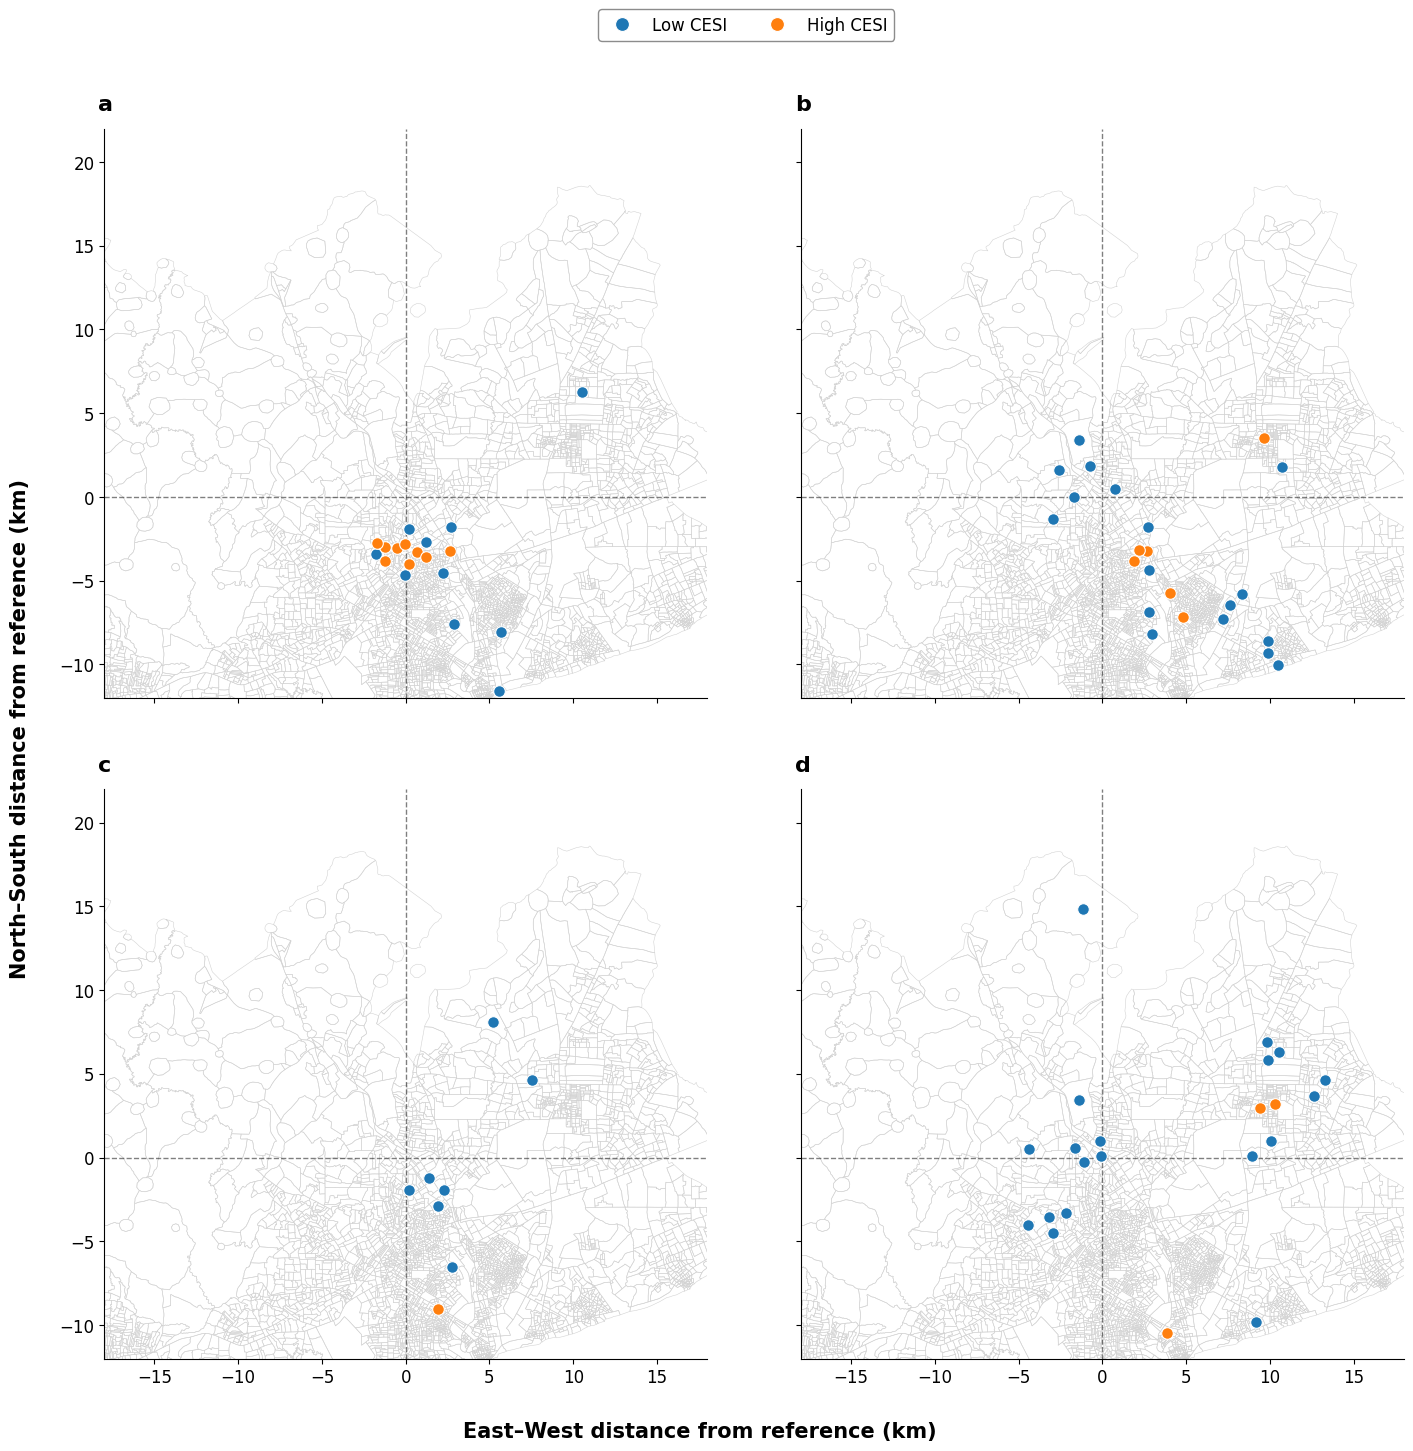

In [55]:
fig, axes, event_centroids = (
    plot_all_same_day_outage_risk_relative(
        base_gdf=filt_all_eas_dem_df_filt,
        summary_df=same_day_summary_df,

        # Events and panel labels
        events=("T", "P", "W", "L"),
        panel_labels=("a", "b", "c", "d"),
        event_titles={
            "T": "",
            "P": "",
            "W": "",
            "L": ""
        },

        # Reference point
        use_union_centroid=True,
        use_km=True,
        x_ref_offset=common_x_ref_offset,
        y_ref_offset=common_y_ref_offset,

        # Basemap
        show_basemap=True,
        basemap_facecolor="none",
        basemap_edgecolor="lightgrey",
        basemap_linewidth=0.4,
        basemap_alpha=1.0,

        # CESI styling
        cesi_colors={
            "Low": "tab:blue",
            "High": "tab:orange"
        },
        cesi_order=("Low", "High"),
        cesi_legend_labels={
            "Low": "Low CESI",
            "High": "High CESI"
        },

        # Point styling
        point_size=70,
        point_edgecolor="white",
        point_linewidth=0.8,
        point_marker="o",
        point_alpha=1.0,

        # Reference lines
        show_reference_lines=True,
        reference_linecolor="black",
        reference_linestyle="--",
        reference_linewidth=1,
        reference_alpha=0.5,

        # Panel labels
        panel_label_x=-0.01,
        panel_label_y=1.06,
        panel_label_fontsize=16,

        # Shared axis-label positions
        x_label_x=0.5,
        x_label_y=0.025,
        y_label_x=0.055,
        y_label_y=0.5,

        # Panel titles
        show_titles=True,
        title_fontsize=15,
        title_fontweight="bold",

        # Common spatial limits
        xlim=common_xlim,
        ylim=common_ylim,

        # Shared legend
        show_legend=True,
        legend_title=None,
        legend_loc="upper center",
        legend_bbox=(0.53, 0.985),
        legend_ncol=2,
        legend_fontsize=12,

        # Figure
        # figsize=(15, 13),
        figsize=(15.5, 15),
        sharex=True,
        sharey=True,

        # Spacing
        top=0.90,
        wspace=0.02,
        hspace=0.16,

        print_count=False,

        # Save figure
        save_path=(
            PLOTS_DIR /
            "elevated_risk_by_CESI_all_events_basemap.png"
        ),
        dpi=300
    )
)

## Temp Clustering 

In [56]:
extreme_temp_df = same_day_summary_df[same_day_summary_df['event'] == 'T'].reset_index(drop=True).drop_duplicates(subset=['ea_code9ch'])

extreme_temp_df = extreme_temp_df.drop(columns=['cesi_level']).merge(eas_to_plot, on = 'ea_code9ch')

extreme_temp_gdf = gpd.GeoDataFrame(
    extreme_temp_df.copy(),
    geometry="geometry",
    crs="EPSG:32630"
)

In [57]:
extreme_temp_gdf

,ea_code9ch,event,odds_ratio,DIST_NAME,geometry,Pcode,cesi_level,BASE_NAM,LOC_NAME
0,30200065,T,3.96,GA WEST,"POLYGON ((802936.258 621311.052, 802943.18 621...",03,High,TABORA: GOD'S GRACE ACADEMY,TABORA
1,30200067,T,3.31,GA WEST,"POLYGON ((802463.854 621647.961, 802463.308 62...",03,Low,TABORA: CHRIST REDEEMER CHURCH INT.,TABORA
2,30200075,T,2.21,GA WEST,"POLYGON ((802762.737 622271.414, 802772.154 62...",03,High,TABORA: ANKOFA ENGINEERING WORKS,TABORA
3,30200076,T,4.23,GA WEST,"POLYGON ((802213.069 622014.405, 802215.029 62...",03,High,TABORA: VICTORY WAY CHAPEL,TABORA
4,30200092,T,3.09,GA WEST,"POLYGON ((803761 621988.013, 803772.049 621983...",03,High,CHANTAN: FOUNTAIN OF FAITH MINISTRIES,CHANTAN
5,30200098,T,2.30,GA WEST,"POLYGON ((803962.527 622254.135, 804013.085 62...",03,High,CHANTAN: LYDIA SACKEY MEMORIAL ENTERPRISE,CHANTAN
6,30200109,T,2.85,GA WEST,"POLYGON ((804195.588 623094.147, 804210.509 62...",03,Low,CHANTAN: SOUND FOUNDATION INT. SCHOOL,CHANTAN
7,30200126,T,3.43,GA WEST,"POLYGON ((804778.425 621723.097, 804804.652 62...",03,High,NII BOI TOWN: JONO ENTERPRISE,NII BOI TOWN
8,30200134,T,3.26,GA WEST,"POLYGON ((805539.666 622127.877, 805528.337 62...",03,Low,NEW ACHIMOTA: ROYAL GARDEN CHINESE RESTAURANT,NEW ACHIMOTA
9,30300069,T,2.54,GA EAST,"POLYGON ((806625.701 623045.078, 806603.848 62...",03,Low,ST THERESA OF AVILA PREP. SCHOOL,DOME


Center method:
mean_centroid

Center coordinates:
x = 805677.17
y = 621269.67

Radius coverage:
 radius_km  number_of_eas  total_eas coverage_percent  captures_all
         1              2         19            10.5%         False
         2              8         19            42.1%         False
         3             13         19            68.4%         False
         4             15         19            78.9%         False
         5             16         19            84.2%         False

Distance summary:
number_of_eas                19.00
median_radius_km              2.20
90_percent_radius_km          6.64
95_percent_radius_km          9.38
minimum_radius_for_all_km    13.40
dtype: float64


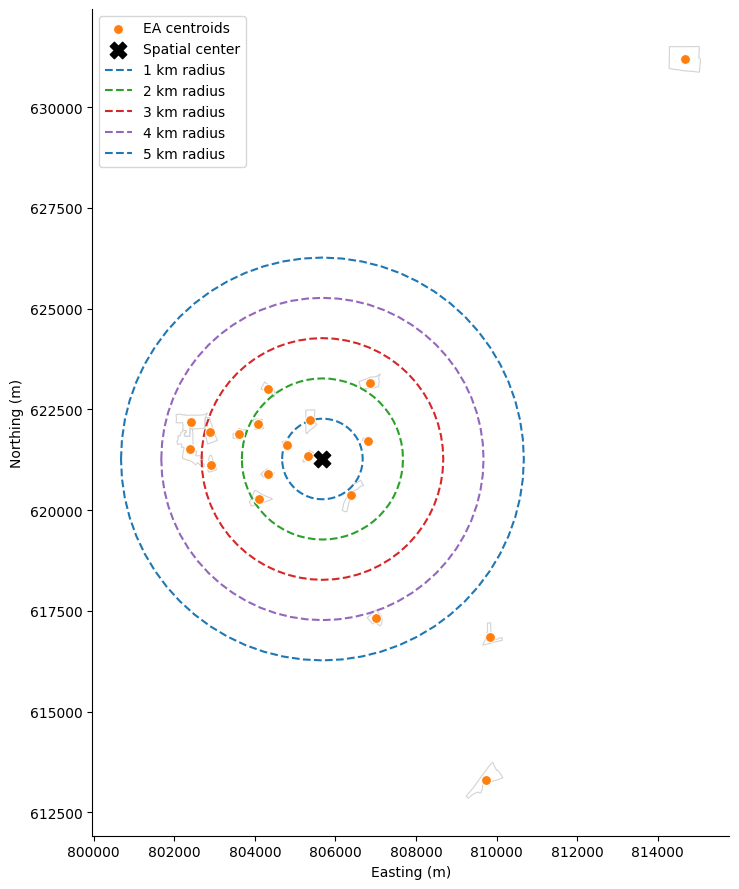

In [58]:
(
    high_cesi_distance_gdf,
    radius_coverage_df,
    high_cesi_center,
    high_cesi_distance_summary
) = summarize_spatial_concentration(
    gdf=extreme_temp_gdf,              ## specify gdf 
    candidate_radii_km=(1,2,3,4,5),
    center_method="mean_centroid",
    plot=True
)

### Plot population, other x'stics 

In [59]:
new_ea

,ea_code9ch,REG_NAME,DIST_CODE,DIST_NAME,Z00_EA_COD,TYP,Z010_EA_CO,SA_NUM,BASE_NAM,testpopden,...,LOC_NAME_e,area_sqkm,nhd,nhd_code,dist_id,# of sites,Total_Pop,mean_elev,mean_slope,geometry
0,30500001,GREATER ACCRA,0305,ADENTA MUNICIPAL,"0303001704A-704Z, 704AA-704",2,0305200001,0.0,MERIDIAN STORE,0.002020,...,TESA,0.116656,381,030500381,ADENTA MUNICIPAL,0,297.240173,45.589148,1.894005,"POLYGON ((816225.671 624616.057, 816220.776 62..."
1,30500002,GREATER ACCRA,0305,ADENTA MUNICIPAL,"0303001704A-704Z, 704AA-704",2,0305200002,0.0,ROGER BARBERING SHOP,0.001345,...,TESA,0.142484,381,030500381,ADENTA MUNICIPAL,0,414.343872,41.963722,1.605005,"POLYGON ((816398.314 624628.21, 816442.655 624..."
2,30500003,GREATER ACCRA,0305,ADENTA MUNICIPAL,0303001702A-702M,2,0305200003,0.0,MOTORWAY DAM,0.007245,...,TESA,0.029212,381,030500381,ADENTA MUNICIPAL,0,98.237907,40.321857,1.773169,"POLYGON ((816639.606 624242.084, 816648.924 62..."
3,30500004,GREATER ACCRA,0305,ADENTA MUNICIPAL,0303001702A-702M,2,0305200004,0.0,HSE # 18 ( OPPOSITE THE MAST),0.000910,...,TESA,0.199589,381,030500381,ADENTA MUNICIPAL,0,478.494873,41.840388,2.384769,"POLYGON ((817189.656 623927.126, 817162.116 62..."
4,30500008,GREATER ACCRA,0305,ADENTA MUNICIPAL,0303001702A-702M,2,0305200008,0.0,THE ANOINTED CHURCH,0.007225,...,TESA / ADGIRIGANO,0.070899,382,030500382,ADENTA MUNICIPAL,0,174.153595,55.139724,1.912093,"POLYGON ((817115.708 624398.183, 817102.74 624..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5014,31100511,GREATER ACCRA,0311,GA CENTRAL,0302004001-C + D,1,0311200511,0.0,GRAND PROVIDER GLOBAL SCHOOL,0.000000,...,ANYAA,0.075771,063,031100063,GA CENTRAL,0,319.512787,56.969524,10.015196,"POLYGON ((799328.266 618849.883, 799325.014 61..."
5015,31100560,GREATER ACCRA,0311,GA CENTRAL,0302014004-A + B,1,0311200560,0.0,ABLEKUMA: LIBERTY ACADEMY,0.000000,...,ANYAA,0.097052,063,031100063,GA CENTRAL,0,290.049805,92.250319,4.302081,"POLYGON ((799696.634 621371.983, 799667.054 62..."
5016,31400041,GREATER ACCRA,0314,KPONE KATAMANSO,0303008003,2,0314100041,0.0,CHURCH OF PENTECOST,0.000000,...,KAKASUNANKA II,0.246664,161,031400161,KPONE KATAMANSO,0,722.054810,50.321738,1.289076,"POLYGON ((831365.155 631876.525, 831329.92 631..."
5017,30802130,GREATER ACCRA,0308302,TMA-TEMA EAST,0303704036,2,0308302130,25.0,DIVINE TOUCH CRECHE,0.008574,...,TEMA COMMUNITY ONE,0.030727,375,030802375,TEMA,0,138.149887,19.656034,1.521026,"POLYGON ((832173.056 625614.715, 832159.81 625..."


In [60]:
new_data_study_area

,ea_code9ch,DIST_NAME,mean_elev_log_inverted,mean_slope_log_inverted,Total_Pop,slum_index,normalized_rainfall,normalized_hot_hours,mean_ndvi,normalized_mean_ndvi,probabilities,norm_pm2.5,inverted_ndvi,flood_risk_add,flood_risk_geo,climate_vul_add,climate_vul_geo,geometry
0,30100007,GA SOUTH,0.556845,0.616470,4218.614746,NaN,0.408259,0.700695,0.121710,0.316666,NaN,0.074425,0.683334,0.566227,0.556293,0.320326,0.315359,"POLYGON ((787530.718 608893.908, 787539.955 60..."
1,30100016,GA SOUTH,0.269221,0.152670,3251.018066,0.002521,0.408771,0.685730,0.150249,0.413845,0.002521,0.119080,0.586155,0.354204,0.315020,0.158602,0.145541,"POLYGON ((791911.069 608977.638, 791894.758 60..."
2,30100018,GA SOUTH,0.651109,0.403002,366.807922,NaN,0.413457,0.680919,0.130681,0.347214,NaN,NaN,0.652786,0.530089,0.515870,0.530089,0.515870,"POLYGON ((792931.089 608393.778, 792912.654 60..."
3,30100057,GA SOUTH,0.904557,0.794258,9138.667969,NaN,0.473068,0.675575,0.181675,0.520857,NaN,0.303563,0.479143,0.662757,0.635253,0.483160,0.469408,"POLYGON ((798023.37 613308.767, 798036.577 613..."
4,30100059,GA SOUTH,0.931378,0.873493,27732.269531,0.001868,0.494935,0.675040,0.078866,0.170775,0.001868,0.359134,0.829225,0.782258,0.760154,0.381087,0.373719,"POLYGON ((801498.303 614362.25, 801501.063 614..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,31300291,LA NKWANANANG MADINA,0.265855,0.547299,308.598633,0.466490,0.291956,0.954035,0.093364,0.220143,0.466490,0.292625,0.779857,0.471242,0.426629,0.410119,0.395248,"POLYGON ((813765.805 629305.242, 813853.337 62..."
334,31300310,LA NKWANANANG MADINA,0.254663,0.472571,1202.071167,0.090383,0.270294,0.954570,0.109302,0.274415,0.090383,0.287551,0.725585,0.430778,0.391958,0.269571,0.256631,"POLYGON ((811832.487 629333.217, 811643.775 62..."
335,31300328,LA NKWANANANG MADINA,0.256943,0.471032,7552.798828,0.032258,0.377228,0.667023,0.123004,0.321073,0.032258,0.244925,0.678927,0.446033,0.419593,0.241072,0.232259,"POLYGON ((813036.279 631092.941, 813016.813 63..."
336,31300407,LA NKWANANANG MADINA,0.265132,0.409789,1719.050537,NaN,0.503779,0.442544,0.241469,0.724464,NaN,0.227673,0.275536,0.363559,0.350437,0.295616,0.289055,"POLYGON ((811220.071 632428, 811219.23 632385...."


In [61]:
filt_all_eas_dem_df

,ea_code9ch,DIST_NAME,mean_elev_log_inverted,mean_slope_log_inverted,geometry
0,30500001,ADENTA MUNICIPAL,0.323514,0.448931,"POLYGON ((816225.671 624616.057, 816220.776 62..."
1,30500002,ADENTA MUNICIPAL,0.337243,0.485467,"POLYGON ((816398.314 624628.21, 816442.655 624..."
2,30500003,ADENTA MUNICIPAL,0.343855,0.463479,"POLYGON ((816639.606 624242.084, 816648.924 62..."
3,30500004,ADENTA MUNICIPAL,0.337730,0.398087,"POLYGON ((817189.656 623927.126, 817162.116 62..."
4,30500008,ADENTA MUNICIPAL,0.292002,0.446834,"POLYGON ((817115.708 624398.183, 817102.74 624..."
...,...,...,...,...,...
5014,31100511,GA CENTRAL,0.286594,0.081424,"POLYGON ((799328.266 618849.883, 799325.014 61..."
5015,31100560,GA CENTRAL,0.206739,0.267892,"POLYGON ((799696.634 621371.983, 799667.054 62..."
5016,31400041,KPONE KATAMANSO,0.307151,0.533838,"POLYGON ((831365.155 631876.525, 831329.92 631..."
5017,30802130,TMA-TEMA EAST,0.462895,0.497326,"POLYGON ((832173.056 625614.715, 832159.81 625..."


<Axes: >

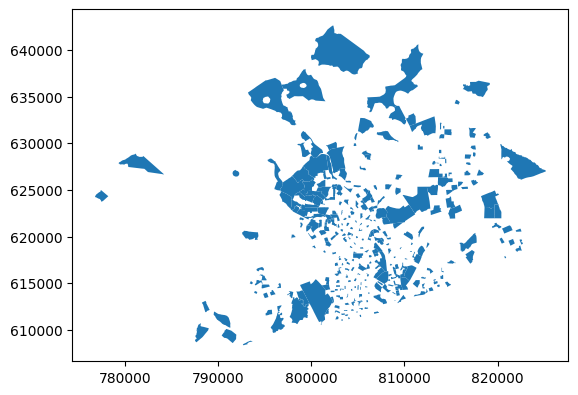

In [62]:
new_data_study_area.plot()

In [63]:
import matplotlib.pyplot as plt


def plot_study_area(
    filt_all_eas_dem_df,
    new_data_study_area,
    color_col,
    figsize=(10, 10),
    cmap="viridis",
    base_facecolor="#eeeeee",
    base_edgecolor="white",
    base_linewidth=0.15,
    overlay_edgecolor="#333333",
    overlay_linewidth=0.25,
    legend=True,
    legend_label=None,
    title=None,
    axis_off=True,
    save_path=None,
    dpi=300,
):
    """
    Plot all EAs as a basemap and overlay the study-area EAs,
    colored according to a specified column.
    """

    if color_col not in new_data_study_area.columns:
        raise ValueError(
            f"'{color_col}' is not in new_data_study_area. "
            f"Available columns:\n{new_data_study_area.columns.tolist()}"
        )

    # Ensure both GeoDataFrames use the same coordinate reference system
    if (
        filt_all_eas_dem_df.crs is not None
        and new_data_study_area.crs is not None
        and filt_all_eas_dem_df.crs != new_data_study_area.crs
    ):
        new_data_study_area = new_data_study_area.to_crs(
            filt_all_eas_dem_df.crs
        )

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # All EAs: basemap
    filt_all_eas_dem_df.plot(
        ax=ax,
        color=base_facecolor,
        edgecolor=base_edgecolor,
        linewidth=base_linewidth,
        zorder=1,
    )

    # Study-area EAs: colored overlay
    legend_kwds = {
        "label": legend_label or color_col.replace("_", " ").title(),
        "shrink": 0.65,
    }

    new_data_study_area.plot(
        ax=ax,
        column=color_col,
        cmap=cmap,
        edgecolor=overlay_edgecolor,
        linewidth=overlay_linewidth,
        legend=legend,
        legend_kwds=legend_kwds if legend else None,
        missing_kwds={
            "color": "#bdbdbd",
            "edgecolor": overlay_edgecolor,
            "label": "Missing",
        },
        zorder=2,
    )

    # Preserve the extent of the full basemap
    xmin, ymin, xmax, ymax = filt_all_eas_dem_df.total_bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(
        title or color_col.replace("_", " ").title(),
        fontsize=14,
        fontweight="bold",
        pad=12,
    )

    ax.set_aspect("equal")

    if axis_off:
        ax.set_axis_off()

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()

    return fig, ax
    

In [72]:
# fig, ax = plot_study_area(
#     filt_all_eas_dem_df=filt_all_eas_dem_df,
#     new_data_study_area=new_data_study_area,
#     color_col="normalized_hot_hours",
#     cmap="YlOrRd",
#     legend_label="Climate Vulnerability Index",
#     title="Climate Vulnerability Across the Study Area",
# )

In [ ]:
normalized_mean_ndvi

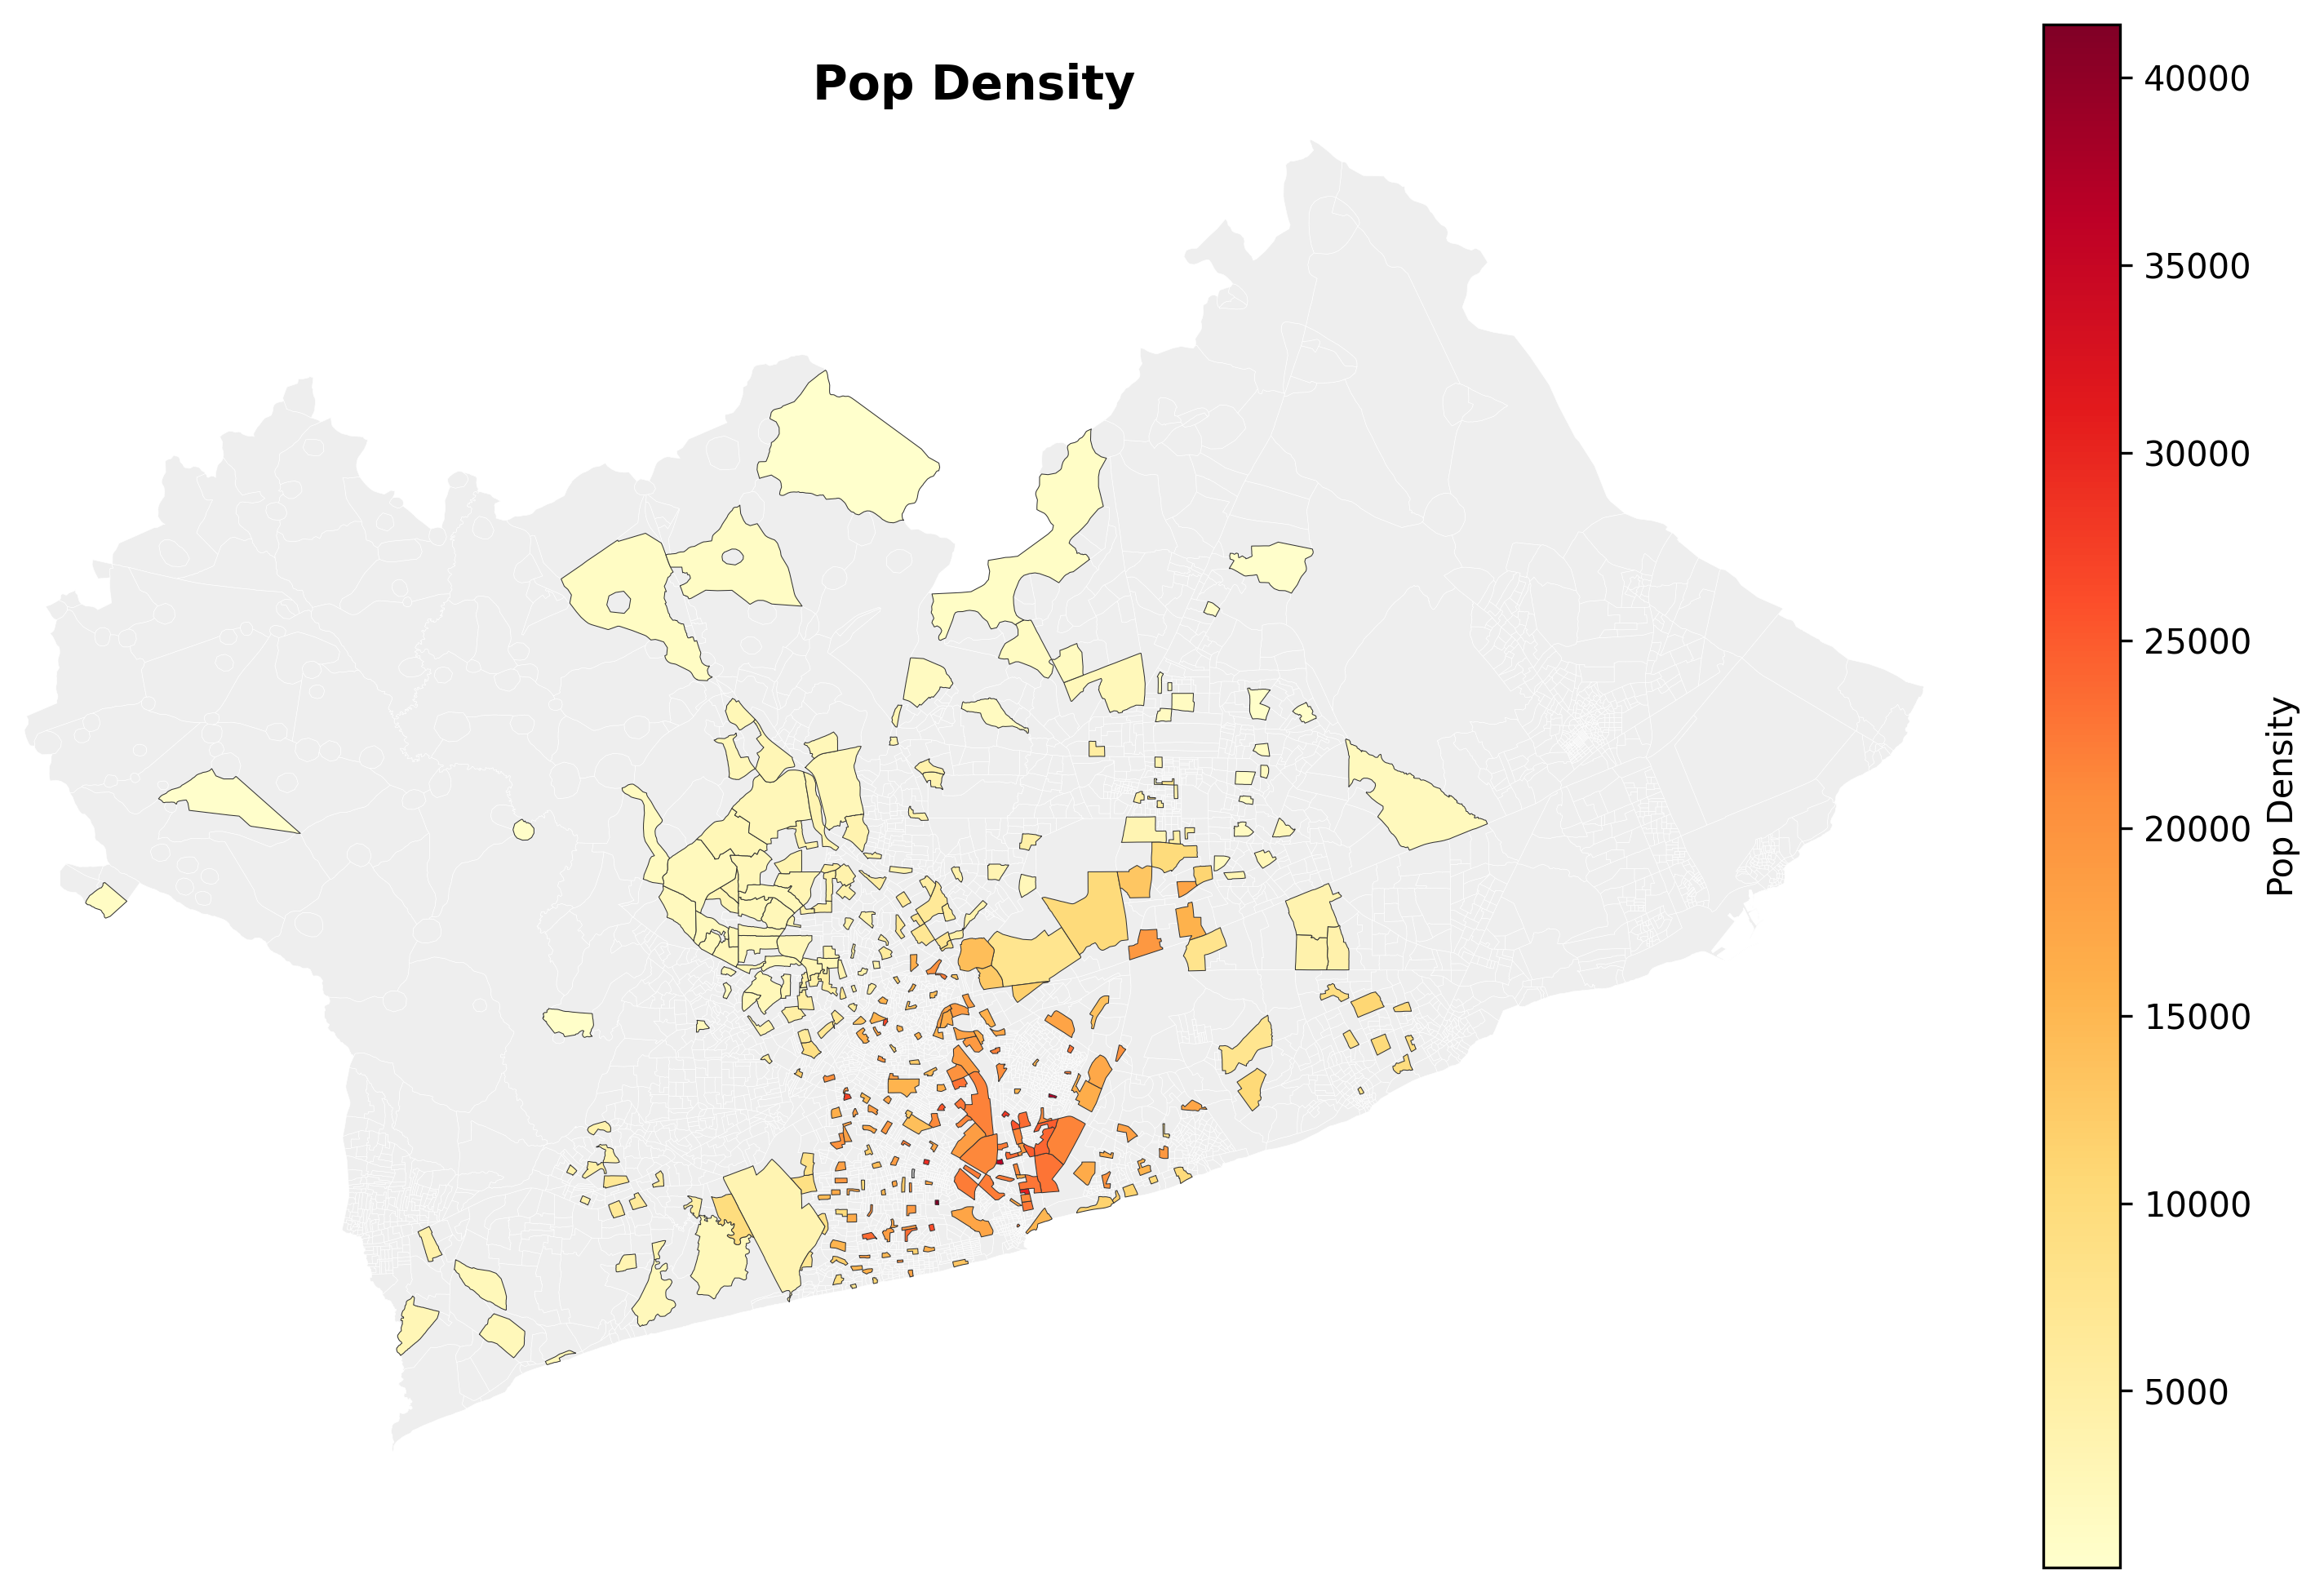

In [76]:
fig, ax = plot_study_area(
    filt_all_eas_dem_df=filt_all_eas_dem_df,
    new_data_study_area=new_data_study_area,
    color_col="pop_density",
    cmap="YlOrRd",
    legend_label="",
    title="",
)

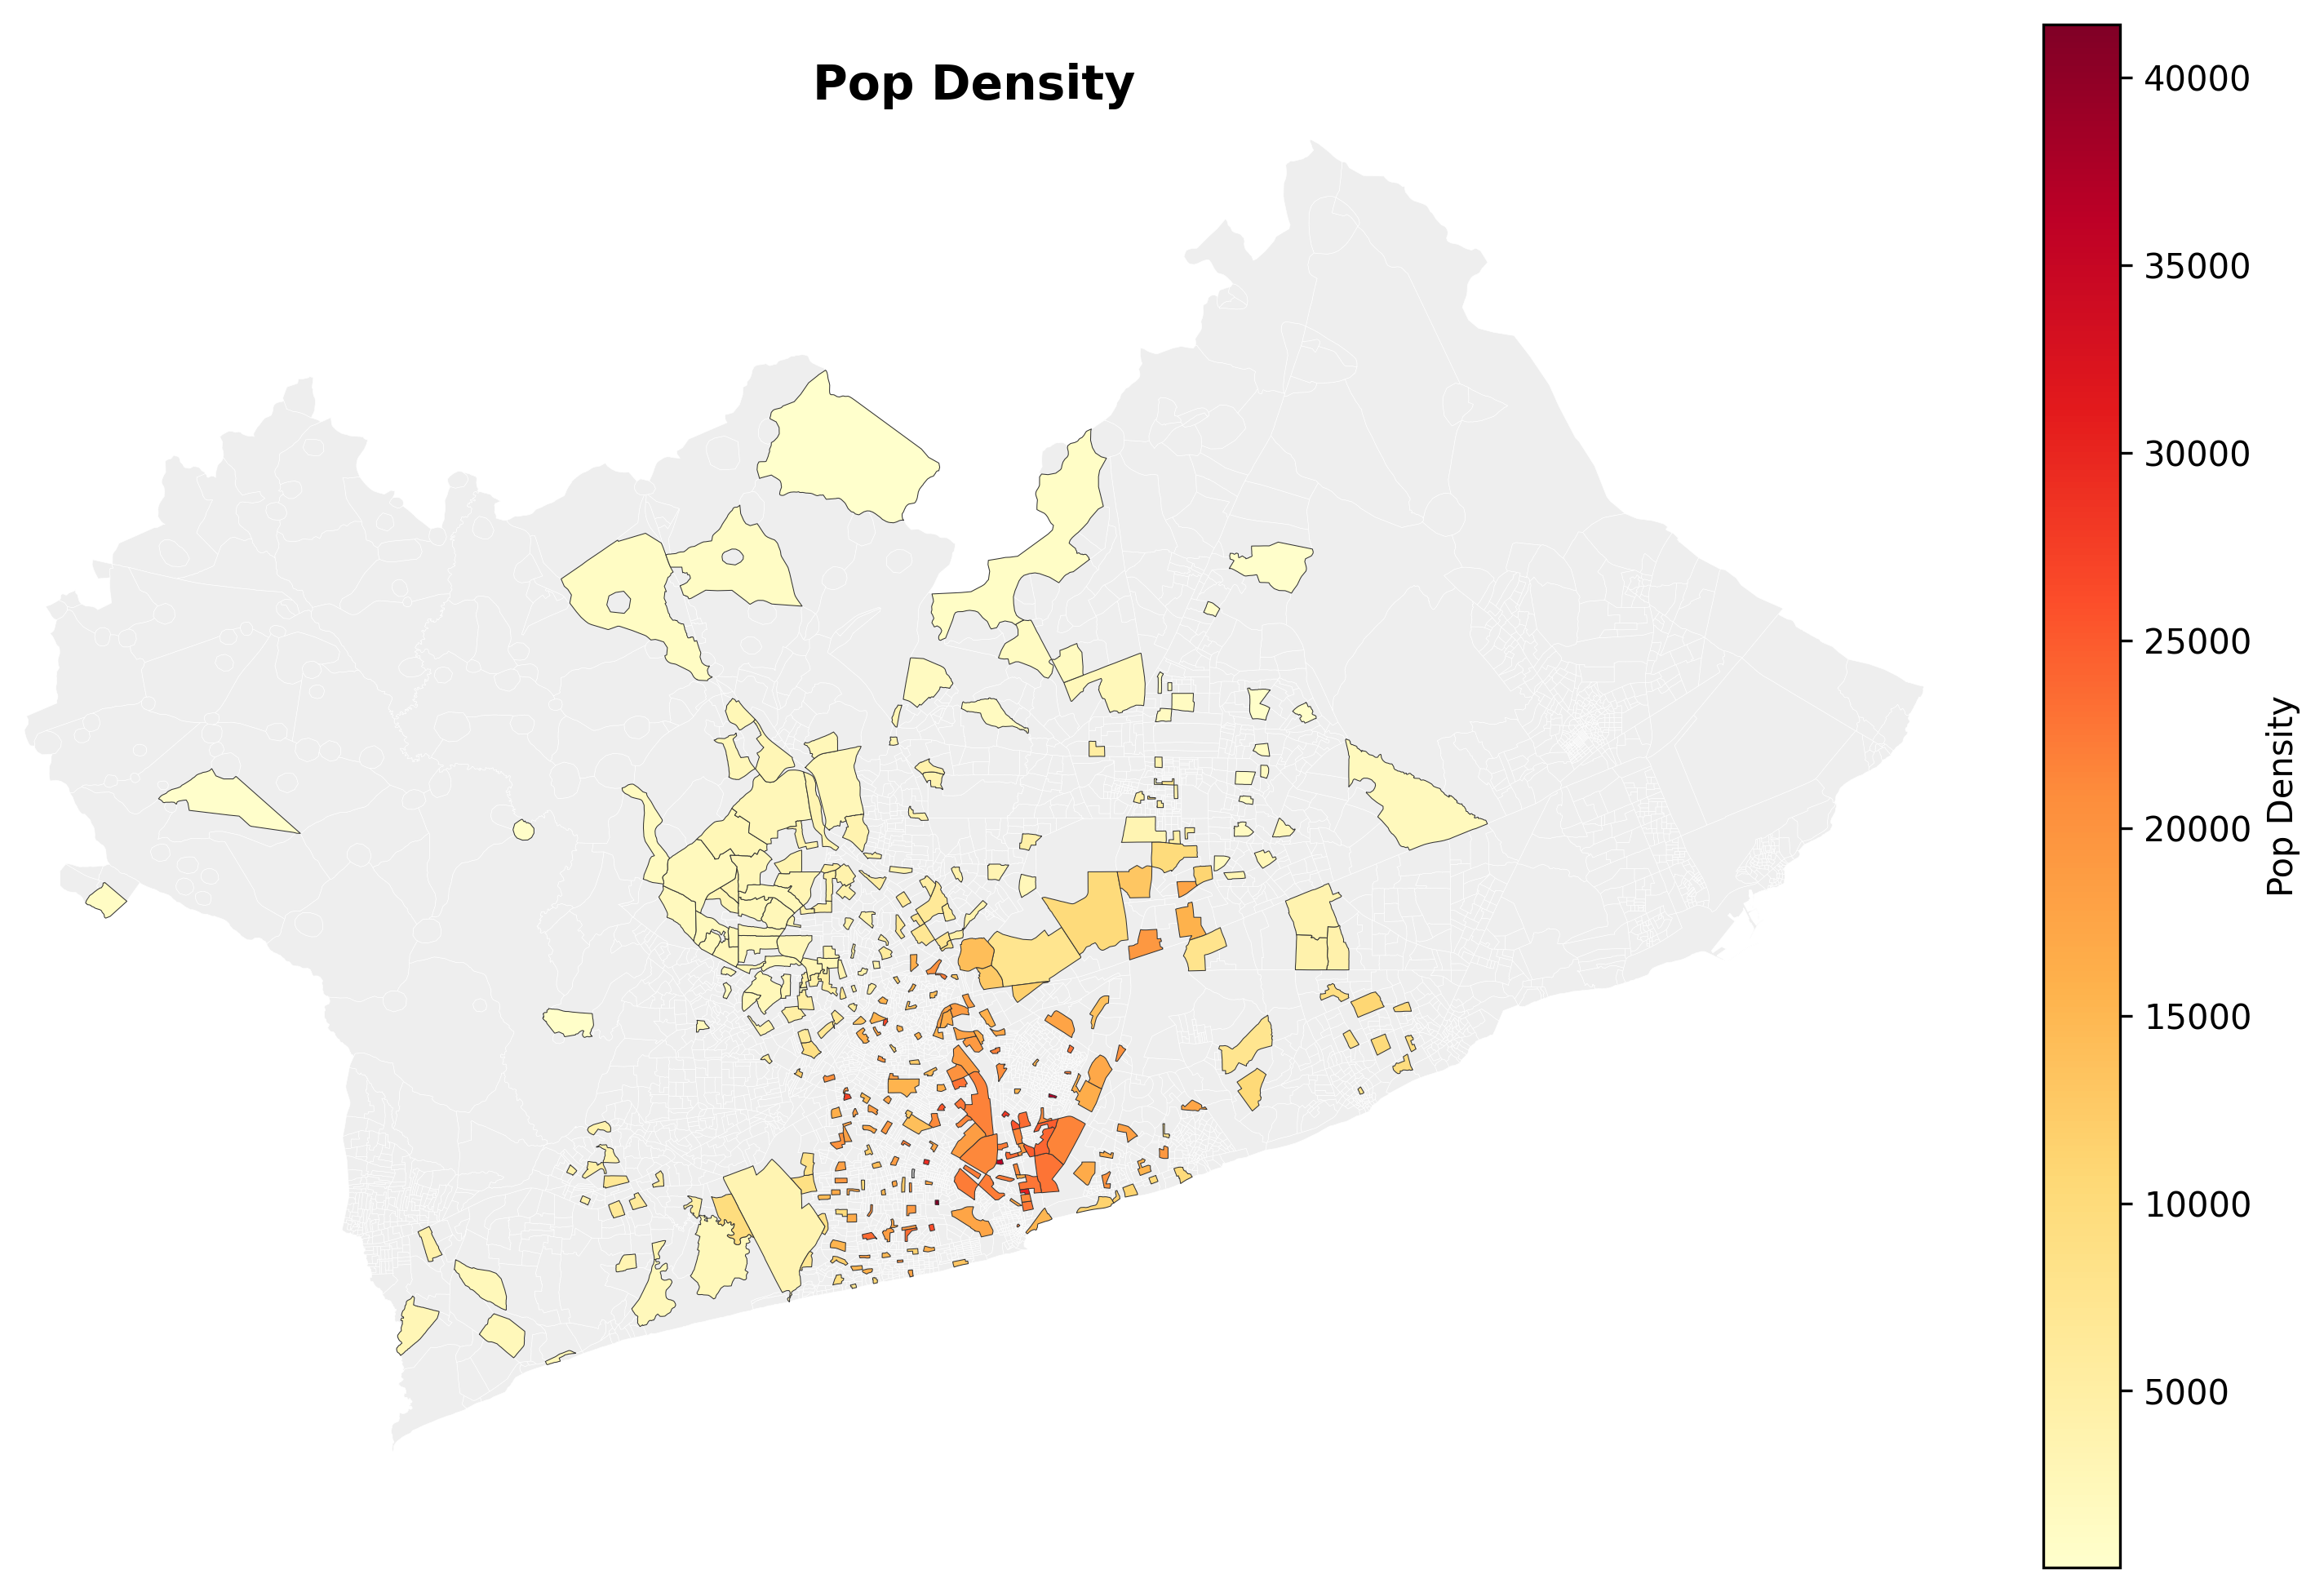

In [77]:
fig, ax = plot_study_area(
    filt_all_eas_dem_df=filt_all_eas_dem_df,
    new_data_study_area=new_data_study_area,
    color_col="pop_density",
    cmap="YlOrRd",
    legend_label="",
    title="",
)

In [ ]:
high_cesi_eas_w_weather
filtered_gdf

In [75]:
new_data_study_area

,ea_code9ch,DIST_NAME,mean_elev_log_inverted,mean_slope_log_inverted,Total_Pop,slum_index,normalized_rainfall,normalized_hot_hours,mean_ndvi,normalized_mean_ndvi,...,norm_pm2.5,inverted_ndvi,flood_risk_add,flood_risk_geo,climate_vul_add,climate_vul_geo,geometry,area_m2,area_km2,pop_density
0,30100007,GA SOUTH,0.556845,0.616470,4218.614746,NaN,0.408259,0.700695,0.121710,0.316666,...,0.074425,0.683334,0.566227,0.556293,0.320326,0.315359,"POLYGON ((787530.718 608893.908, 787539.955 60...",1.434775e+06,1.434775,2940.261469
1,30100016,GA SOUTH,0.269221,0.152670,3251.018066,0.002521,0.408771,0.685730,0.150249,0.413845,...,0.119080,0.586155,0.354204,0.315020,0.158602,0.145541,"POLYGON ((791911.069 608977.638, 791894.758 60...",1.355792e+06,1.355792,2397.874317
2,30100018,GA SOUTH,0.651109,0.403002,366.807922,NaN,0.413457,0.680919,0.130681,0.347214,...,NaN,0.652786,0.530089,0.515870,0.530089,0.515870,"POLYGON ((792931.089 608393.778, 792912.654 60...",1.379830e+05,0.137983,2658.356077
3,30100057,GA SOUTH,0.904557,0.794258,9138.667969,NaN,0.473068,0.675575,0.181675,0.520857,...,0.303563,0.479143,0.662757,0.635253,0.483160,0.469408,"POLYGON ((798023.37 613308.767, 798036.577 613...",3.726385e+06,3.726385,2452.421643
4,30100059,GA SOUTH,0.931378,0.873493,27732.269531,0.001868,0.494935,0.675040,0.078866,0.170775,...,0.359134,0.829225,0.782258,0.760154,0.381087,0.373719,"POLYGON ((801498.303 614362.25, 801501.063 614...",8.134398e+06,8.134398,3409.258978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,31300291,LA NKWANANANG MADINA,0.265855,0.547299,308.598633,0.466490,0.291956,0.954035,0.093364,0.220143,...,0.292625,0.779857,0.471242,0.426629,0.410119,0.395248,"POLYGON ((813765.805 629305.242, 813853.337 62...",8.822681e+04,0.088227,3497.787610
334,31300310,LA NKWANANANG MADINA,0.254663,0.472571,1202.071167,0.090383,0.270294,0.954570,0.109302,0.274415,...,0.287551,0.725585,0.430778,0.391958,0.269571,0.256631,"POLYGON ((811832.487 629333.217, 811643.775 62...",2.242805e+05,0.224280,5359.677899
335,31300328,LA NKWANANANG MADINA,0.256943,0.471032,7552.798828,0.032258,0.377228,0.667023,0.123004,0.321073,...,0.244925,0.678927,0.446033,0.419593,0.241072,0.232259,"POLYGON ((813036.279 631092.941, 813016.813 63...",3.024213e+06,3.024213,2497.442484
336,31300407,LA NKWANANANG MADINA,0.265132,0.409789,1719.050537,NaN,0.503779,0.442544,0.241469,0.724464,...,0.227673,0.275536,0.363559,0.350437,0.295616,0.289055,"POLYGON ((811220.071 632428, 811219.23 632385....",9.360211e+05,0.936021,1836.550974


In [74]:
# Confirm that the CRS is projected
print(new_data_study_area.crs)

if new_data_study_area.crs is None:
    raise ValueError(
        "The GeoDataFrame has no CRS. Set its correct CRS before calculating area."
    )

if new_data_study_area.crs.is_geographic:
    raise ValueError(
        "The GeoDataFrame uses a geographic CRS. Reproject it to an appropriate "
        "projected CRS before calculating area."
    )

# Calculate polygon area
new_data_study_area["area_m2"] = new_data_study_area.geometry.area
new_data_study_area["area_km2"] = (
    new_data_study_area["area_m2"] / 1_000_000
)

# Calculate population density: people per km²
new_data_study_area["pop_density"] = (
    new_data_study_area["Total_Pop"]
    / new_data_study_area["area_km2"]
)

new_data_study_area[
    ["ea_code9ch", "Total_Pop", "area_km2", "pop_density"]
].head()

EPSG:32630


,ea_code9ch,Total_Pop,area_km2,pop_density
0,30100007,4218.614746,1.434775,2940.261469
1,30100016,3251.018066,1.355792,2397.874317
2,30100018,366.807922,0.137983,2658.356077
3,30100057,9138.667969,3.726385,2452.421643
4,30100059,27732.269531,8.134398,3409.258978


In [79]:
high_cesi_eas_w_weather

,ea_code9ch,DIST_NAME,geometry,Pcode,cesi_level,BASE_NAM,LOC_NAME,centroid_x,centroid_y
0,30200065,GA WEST,"POLYGON ((802936.258 621311.052, 802943.18 621...",03,High,TABORA: GOD'S GRACE ACADEMY,TABORA,802920.021797,621121.373457
1,30200075,GA WEST,"POLYGON ((802762.737 622271.414, 802772.154 62...",03,High,TABORA: ANKOFA ENGINEERING WORKS,TABORA,802878.027511,621948.200687
2,30200076,GA WEST,"POLYGON ((802213.069 622014.405, 802215.029 62...",03,High,TABORA: VICTORY WAY CHAPEL,TABORA,802424.277329,622179.137507
3,30200092,GA WEST,"POLYGON ((803761 621988.013, 803772.049 621983...",03,High,CHANTAN: FOUNTAIN OF FAITH MINISTRIES,CHANTAN,803618.529429,621887.891858
4,30200098,GA WEST,"POLYGON ((803962.527 622254.135, 804013.085 62...",03,High,CHANTAN: LYDIA SACKEY MEMORIAL ENTERPRISE,CHANTAN,804087.927903,622134.470546
5,30200126,GA WEST,"POLYGON ((804778.425 621723.097, 804804.652 62...",03,High,NII BOI TOWN: JONO ENTERPRISE,NII BOI TOWN,804793.026348,621616.672822
6,30402283,AMA-ABLEKUMA CENTRAL,"POLYGON ((806075.777 615669.44, 806048.853 615...",03,High,TAKORADI/CAPE COAST LORRY STATION,MATAHEKO,806067.964910,615865.188180
7,30403138,AMA-ASHIEDU KETEKE,"POLYGON ((808213.142 614015.974, 808194.465 61...",03,High,31ST_DECEMBER_MARKET,KORLE DUDOR,808017.523588,614435.677095
8,30407042,AMA-AYAWASO CENTRAL,"POLYGON ((808858.224 617848.034, 808911.314 61...",03,High,GROOVY PUB,NEW TOWN,808948.504205,617778.573133
9,30407084,AMA-AYAWASO CENTRAL,"POLYGON ((808347.896 619284.124, 808348.121 61...",03,High,MANDELA SPOT,ALAJO,808211.028531,619165.978235


In [78]:
filtered_gdf

,ea_code9ch,DIST_NAME,geometry,Pcode,cesi_level,BASE_NAM,LOC_NAME,centroid_x,centroid_y
0,30200065,GA WEST,"POLYGON ((802936.258 621311.052, 802943.18 621...",03,High,TABORA: GOD'S GRACE ACADEMY,TABORA,802920.021797,621121.373457
1,30200075,GA WEST,"POLYGON ((802762.737 622271.414, 802772.154 62...",03,High,TABORA: ANKOFA ENGINEERING WORKS,TABORA,802878.027511,621948.200687
2,30200076,GA WEST,"POLYGON ((802213.069 622014.405, 802215.029 62...",03,High,TABORA: VICTORY WAY CHAPEL,TABORA,802424.277329,622179.137507
3,30200092,GA WEST,"POLYGON ((803761 621988.013, 803772.049 621983...",03,High,CHANTAN: FOUNTAIN OF FAITH MINISTRIES,CHANTAN,803618.529429,621887.891858
4,30200098,GA WEST,"POLYGON ((803962.527 622254.135, 804013.085 62...",03,High,CHANTAN: LYDIA SACKEY MEMORIAL ENTERPRISE,CHANTAN,804087.927903,622134.470546
5,30200126,GA WEST,"POLYGON ((804778.425 621723.097, 804804.652 62...",03,High,NII BOI TOWN: JONO ENTERPRISE,NII BOI TOWN,804793.026348,621616.672822
6,30410135,AMA-OKAIKOI NORTH,"POLYGON ((806062.296 620993.824, 806024.886 62...",03,High,HEAVEN GATE,ACHIMOTA,806054.572869,621105.073028
7,30410146,AMA-OKAIKOI NORTH,"POLYGON ((806749.31 621682.676, 806731.41 6216...",03,High,EPP BOOKSHOP,ACHIMOTA,806802.920019,621722.231078
8,30410175,AMA-OKAIKOI NORTH,"POLYGON ((804468.932 620897, 804463.362 620882...",03,High,COSMOS PREP. SCH. DEPT.,NII BOI TOWN,804321.639797,620893.993474
9,30410186,AMA-OKAIKOI NORTH,"POLYGON ((805202.521 621185.763, 805190.784 62...",03,High,DON-MI YORK'S NEST,ACHIMOTA,805330.032143,621335.185596


In [80]:
import matplotlib.pyplot as plt


def plot_study_area_with_centroids(
    base_gdf,
    study_area_gdf,
    centroid_gdf,
    color_col,
    figsize=(10, 10),
    dpi=300,
    title=None,
    save_path=None,
    base_facecolor="#eeeeee",
    base_edgecolor="white",
    base_linewidth=0.15,
    cmap="viridis",
    overlay_edgecolor="#333333",
    overlay_linewidth=0.25,
    show_colorbar=True,
    colorbar_label=None,
    centroid_color="red",
    centroid_marker="*",
    centroid_size=90,
    centroid_edgecolor="black",
    centroid_linewidth=0.5,
    centroid_label="EA centroids",
    axis_off=True,
):
    """Plot a basemap, colored study-area polygons, and centroid stars."""

    if color_col not in study_area_gdf.columns:
        raise ValueError(
            f"'{color_col}' is not in study_area_gdf.\n"
            f"Available columns: {study_area_gdf.columns.tolist()}"
        )

    for name, gdf in {
        "base_gdf": base_gdf,
        "study_area_gdf": study_area_gdf,
        "centroid_gdf": centroid_gdf,
    }.items():
        if gdf.crs is None:
            raise ValueError(f"{name} does not have a defined CRS.")

    base_plot = base_gdf.copy()
    study_plot = study_area_gdf.to_crs(base_plot.crs)
    centroid_plot = centroid_gdf.to_crs(base_plot.crs)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    base_plot.plot(
        ax=ax,
        color=base_facecolor,
        edgecolor=base_edgecolor,
        linewidth=base_linewidth,
        zorder=1,
    )

    legend_kwds = {
        "label": colorbar_label or color_col.replace("_", " ").title(),
        "shrink": 0.65,
    }

    study_plot.plot(
        ax=ax,
        column=color_col,
        cmap=cmap,
        edgecolor=overlay_edgecolor,
        linewidth=overlay_linewidth,
        legend=show_colorbar,
        legend_kwds=legend_kwds if show_colorbar else None,
        missing_kwds={
            "color": "#bdbdbd",
            "edgecolor": overlay_edgecolor,
            "label": "Missing",
        },
        zorder=2,
    )

    ax.scatter(
        centroid_plot["centroid_x"],
        centroid_plot["centroid_y"],
        color=centroid_color,
        marker=centroid_marker,
        s=centroid_size,
        edgecolors=centroid_edgecolor,
        linewidths=centroid_linewidth,
        label=centroid_label,
        zorder=3,
    )

    xmin, ymin, xmax, ymax = base_plot.total_bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")

    ax.set_title(
        title or color_col.replace("_", " ").title(),
        fontsize=14,
        fontweight="bold",
        pad=12,
    )

    ax.legend(
        loc="lower right",
        frameon=True,
        facecolor="white",
        edgecolor="#555555",
        fontsize=10,
    )

    if axis_off:
        ax.set_axis_off()

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
            facecolor="white",
        )

    return fig, ax

/tmp/ipykernel_68370/374173097.py:104: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(


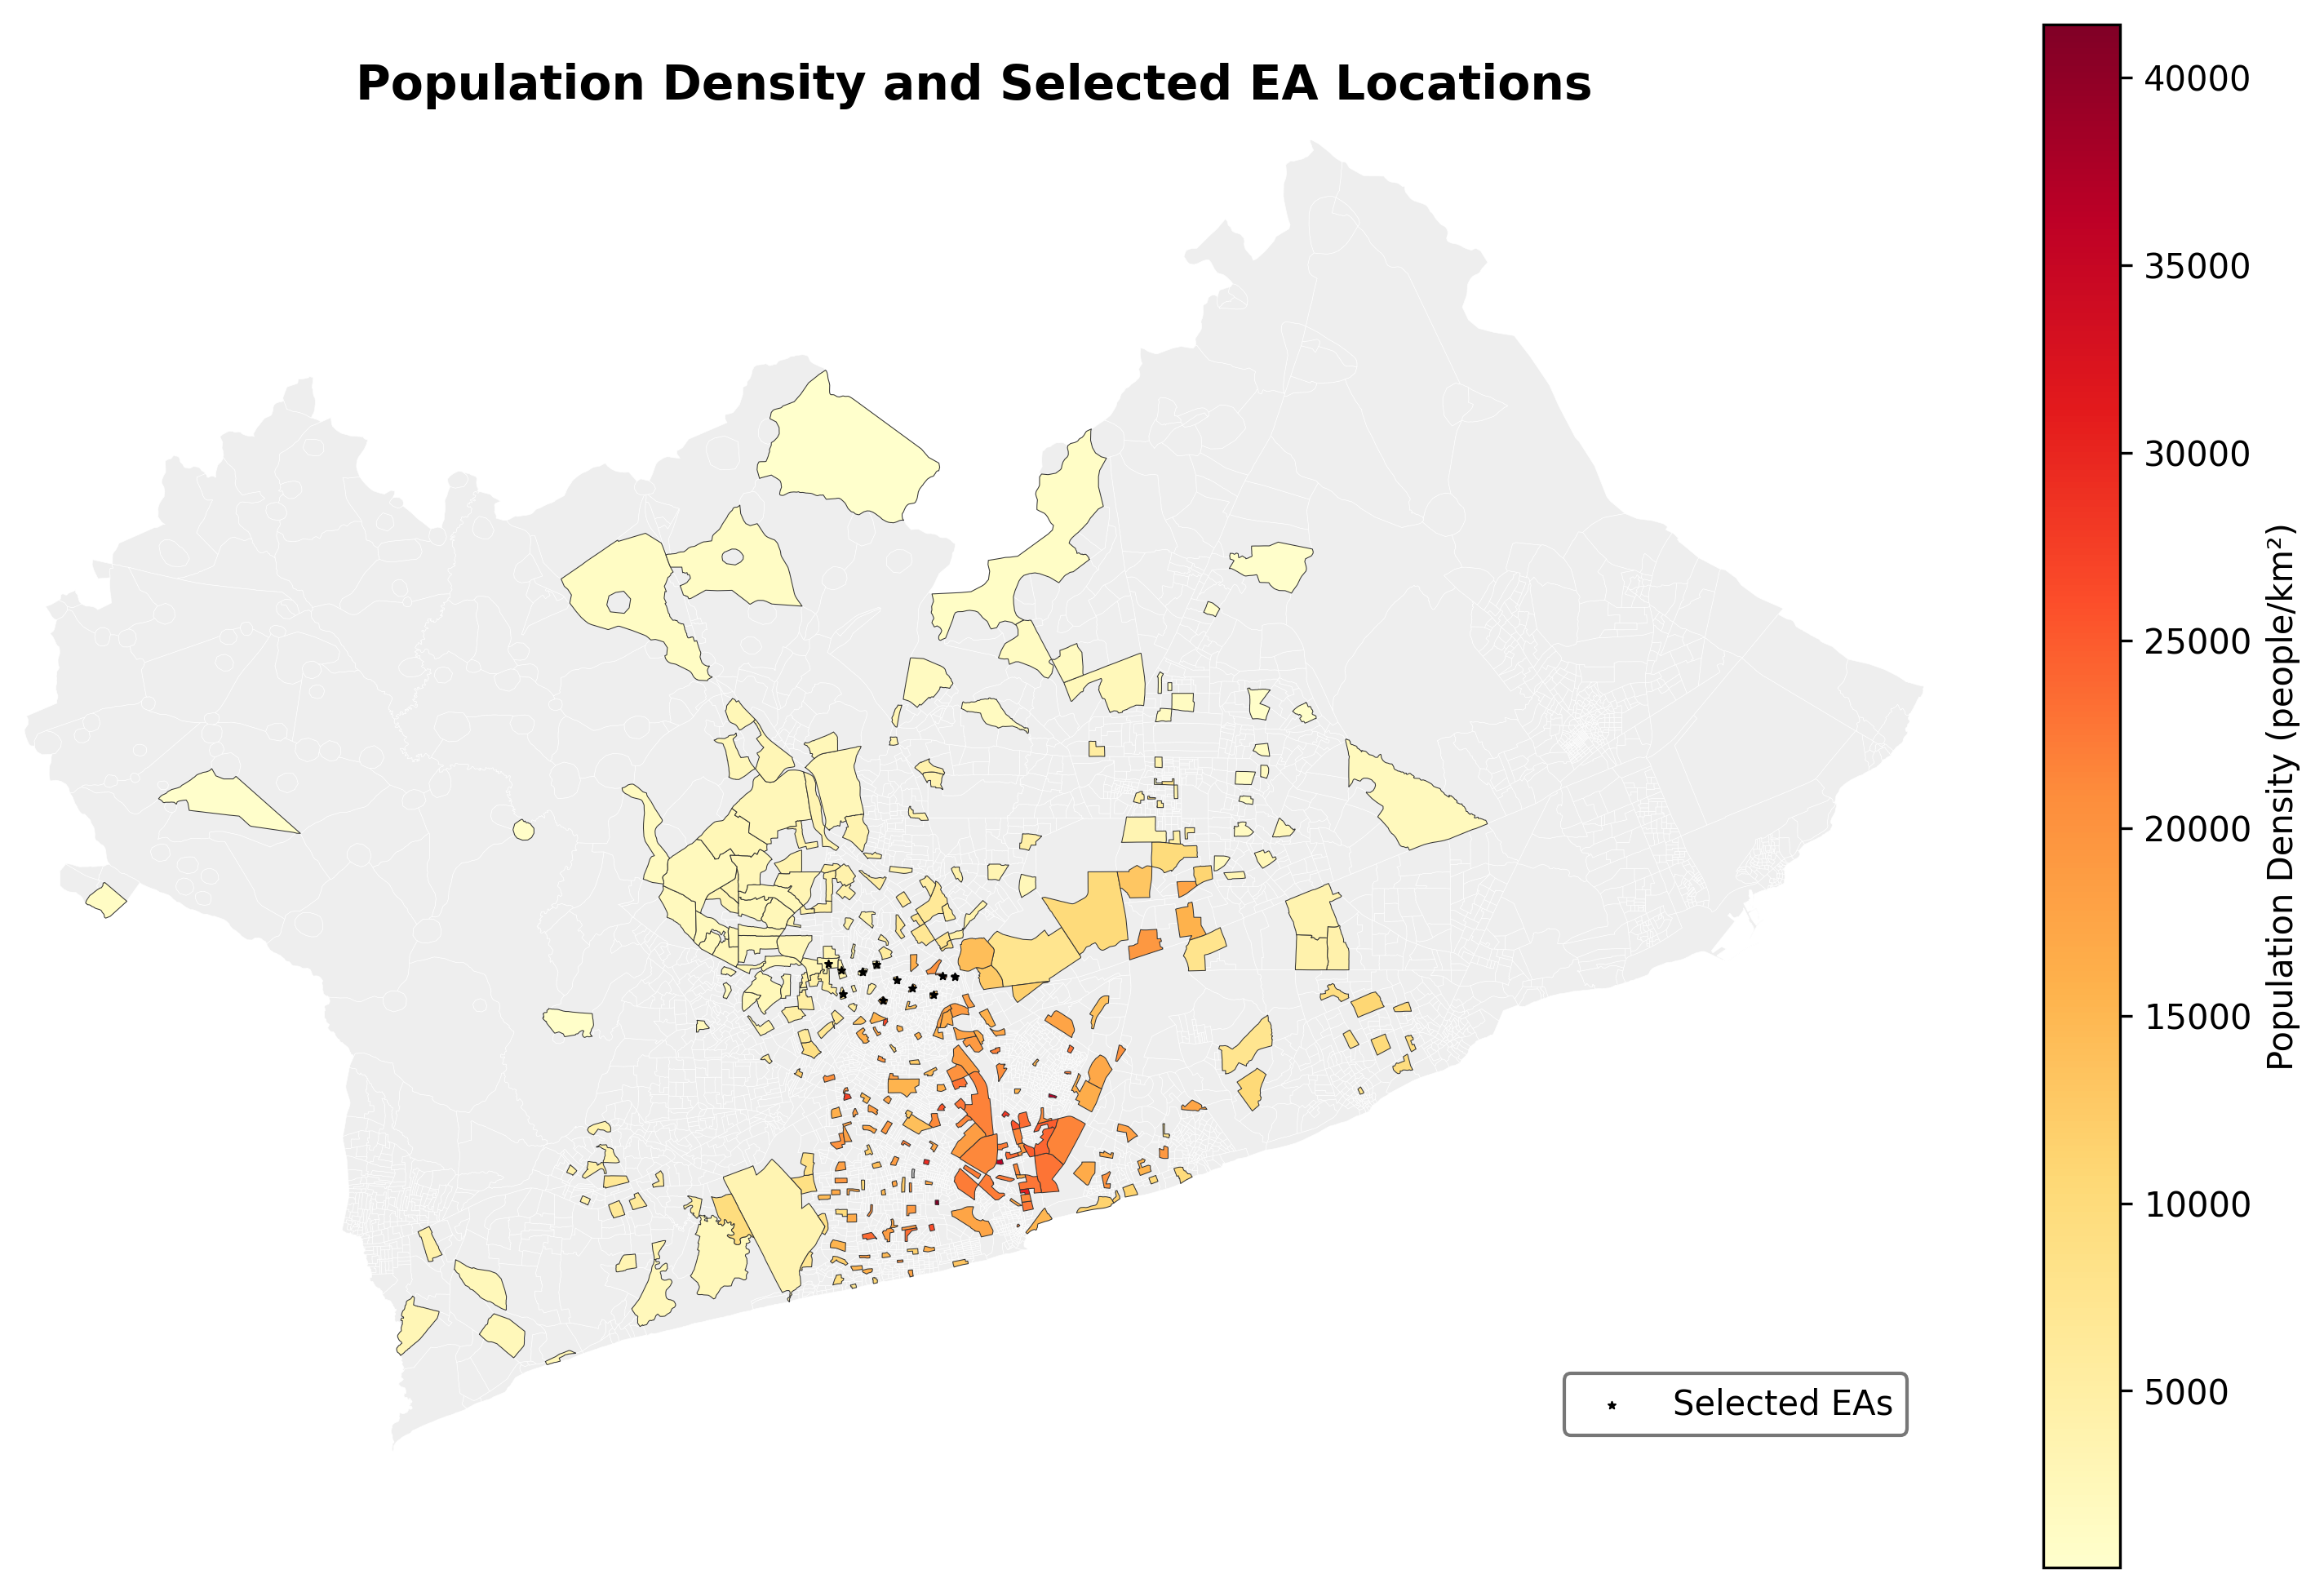

In [84]:
fig, ax = plot_study_area_with_centroids(
    base_gdf=filt_all_eas_dem_df,
    study_area_gdf=new_data_study_area,
    centroid_gdf=filtered_gdf,
    color_col="pop_density",
    cmap="YlOrRd",
    colorbar_label="Population Density (people/km²)",
    centroid_color="black",
    centroid_marker="*",
    centroid_size=5,
    centroid_label="Selected EAs",
    title="Population Density and Selected EA Locations",
    save_path=None,
)

plt.show()

In [88]:
ea_weather_totals = pd.read_csv(DATA_DIR / 'ea_weather_totals.csv')

In [89]:
ea_weather_totals

,ea_code9ch,total_hot_hours,total_windy_hours,total_hot_days,total_windy_days,total_precip_days,total_lightning_days,total_PL_days,total_PWL_days,total_precipitation,total_lightning_count,total_observed_days
0,30200002,865,721,51,28,33,24,13,0,2173.51,616.0,730
1,30200012,868,721,49,28,33,40,18,2,2117.71,1066.0,730
2,30200013,870,721,46,28,34,15,11,2,2143.81,272.0,730
3,30200014,867,721,46,28,34,23,13,2,2157.92,641.0,730
4,30200015,2598,2163,138,84,102,150,54,6,6399.38,3231.0,730
...,...,...,...,...,...,...,...,...,...,...,...,...
209,31300291,1247,546,83,14,32,54,13,2,1827.09,1439.0,730
210,31300310,1254,546,87,14,32,39,14,2,1787.50,1849.0,730
211,31300328,963,546,52,14,30,75,19,2,1863.51,5893.0,730
212,31300407,732,489,19,21,30,78,20,8,1927.47,4494.0,730


In [92]:
df_new = new_data_study_area.merge(ea_weather_totals, on = 'ea_code9ch')

In [96]:
df_new.columns

Index(['ea_code9ch', 'DIST_NAME', 'mean_elev_log_inverted',
       'mean_slope_log_inverted', 'Total_Pop', 'slum_index',
       'normalized_rainfall', 'normalized_hot_hours', 'mean_ndvi',
       'normalized_mean_ndvi', 'probabilities', 'norm_pm2.5', 'inverted_ndvi',
       'flood_risk_add', 'flood_risk_geo', 'climate_vul_add',
       'climate_vul_geo', 'geometry', 'area_m2', 'area_km2', 'pop_density',
       'total_hot_hours', 'total_windy_hours', 'total_hot_days',
       'total_windy_days', 'total_precip_days', 'total_lightning_days',
       'total_PL_days', 'total_PWL_days', 'total_precipitation',
       'total_lightning_count', 'total_observed_days'],
      dtype='object')

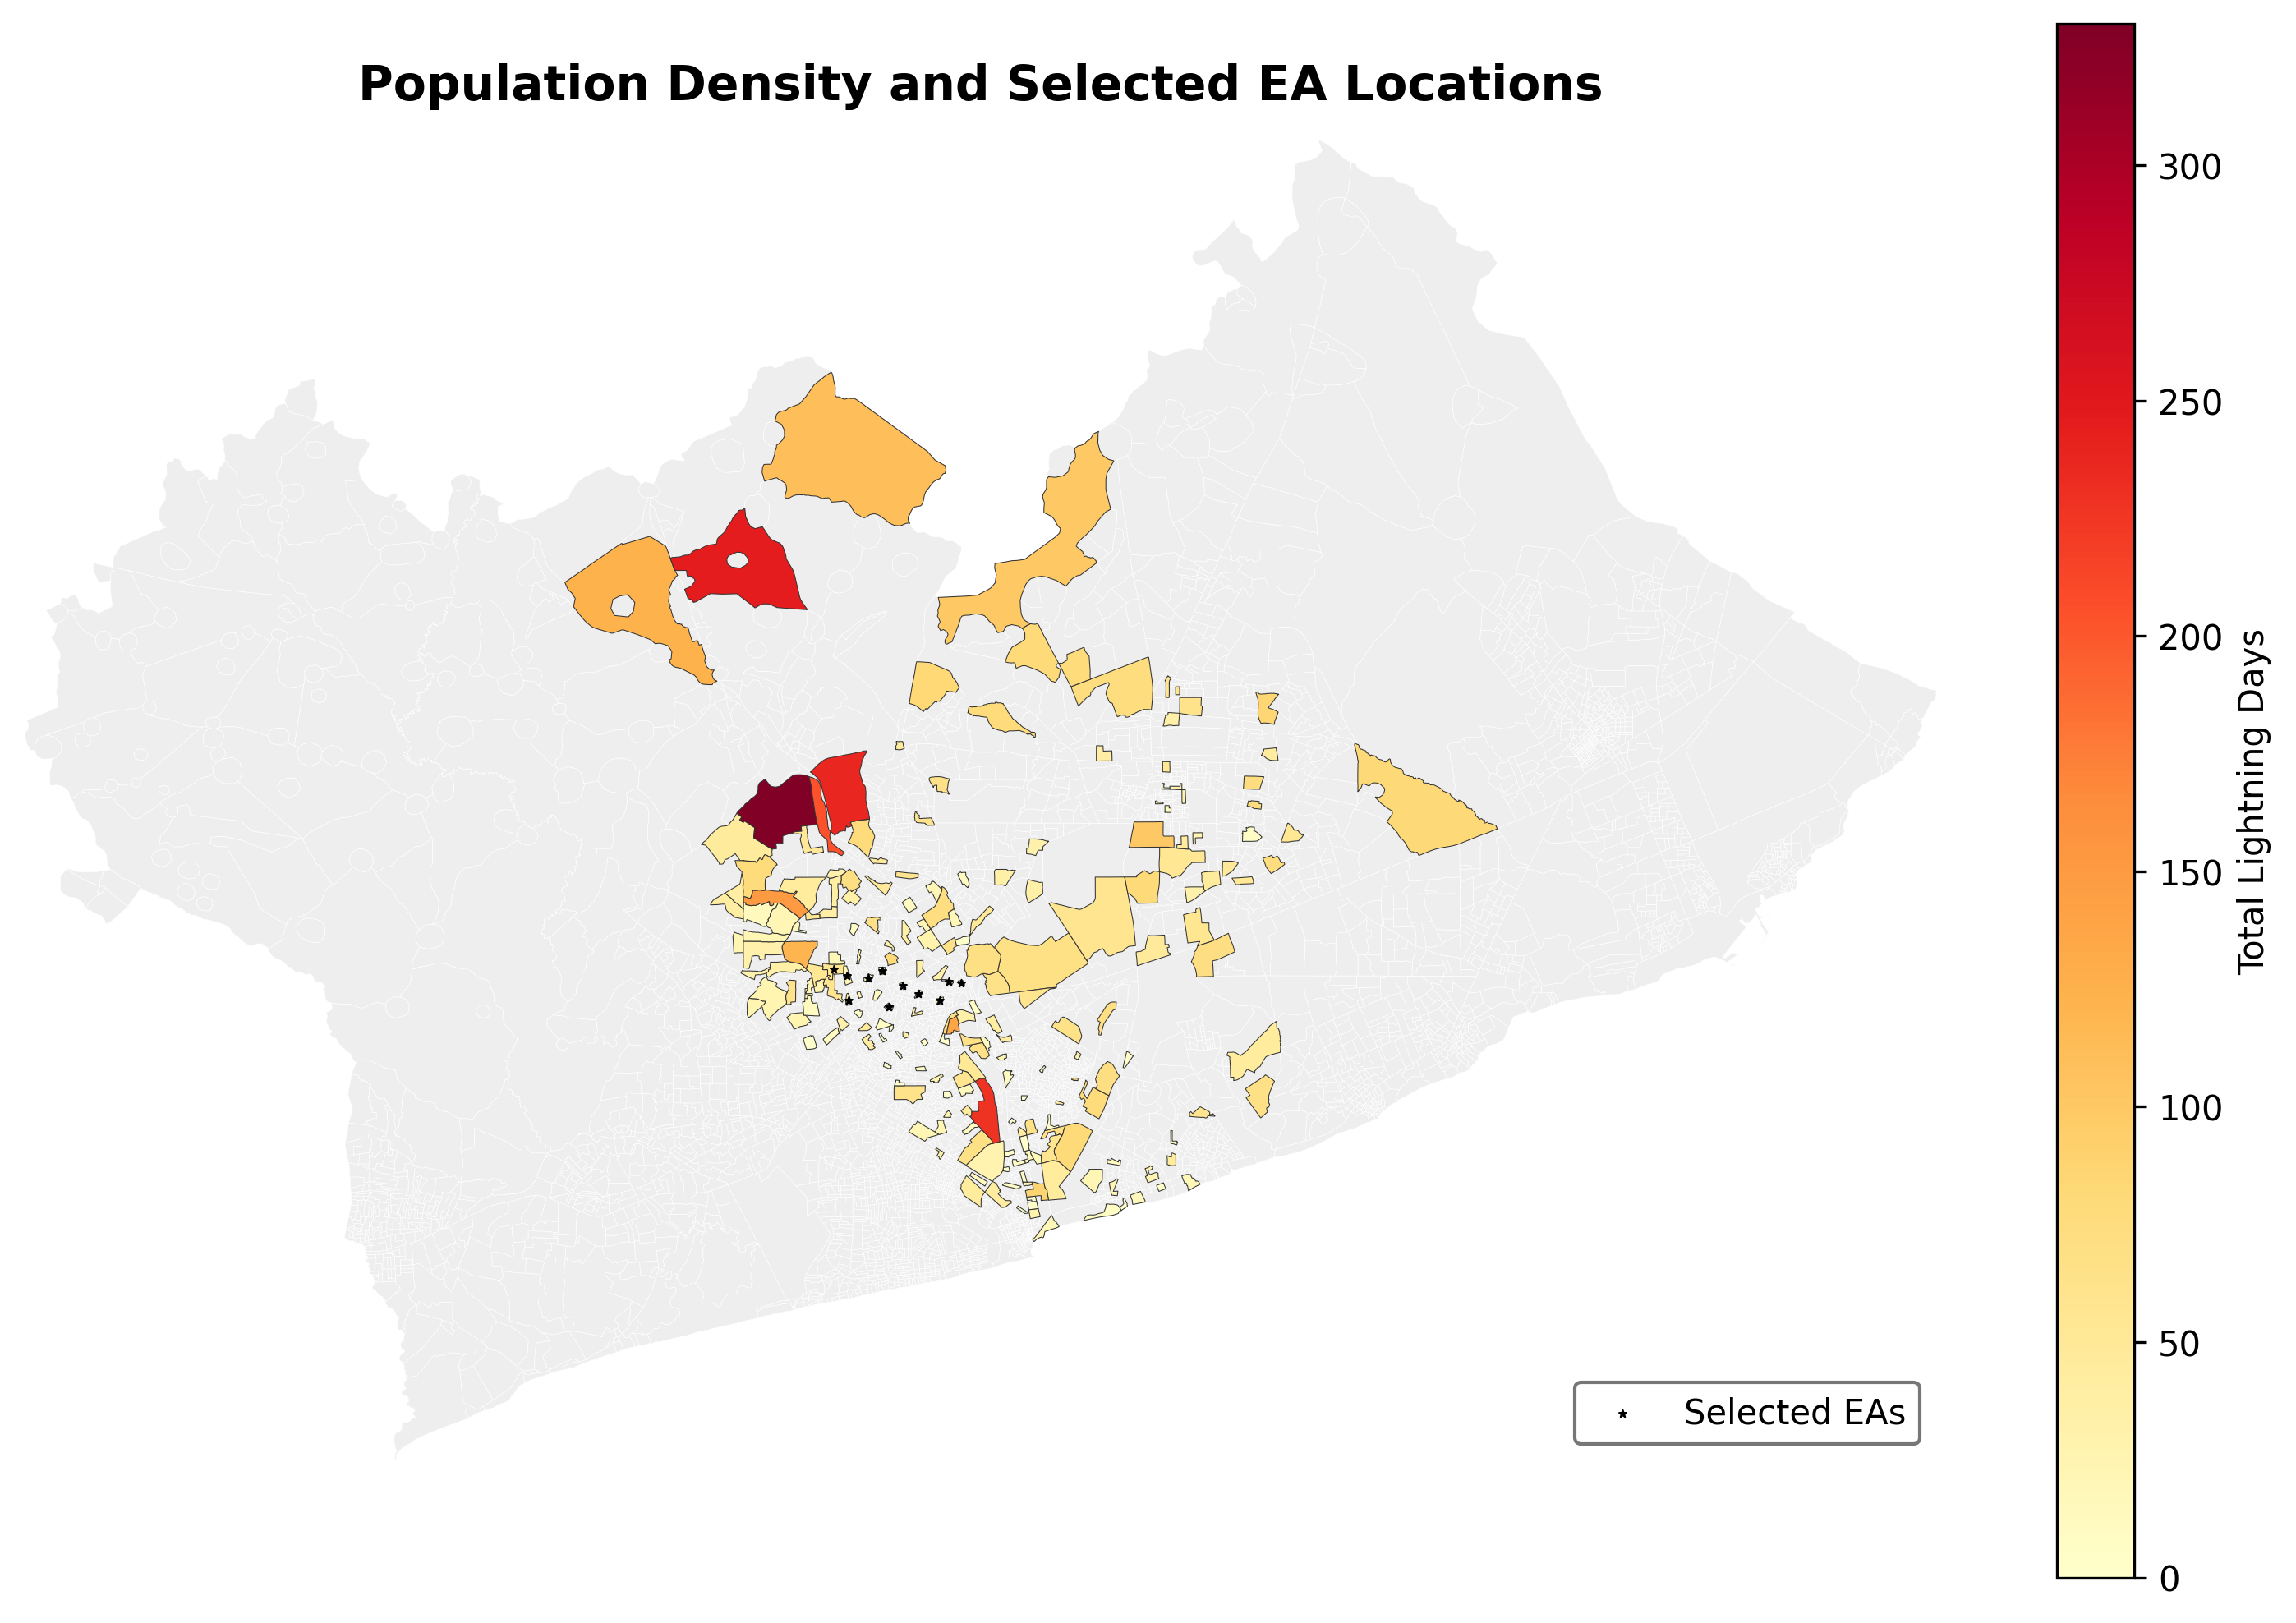

In [100]:
fig, ax = plot_study_area_with_centroids(
    base_gdf=filt_all_eas_dem_df,
    study_area_gdf=df_new,
    centroid_gdf=filtered_gdf,
    color_col="total_lightning_days",
    cmap="YlOrRd",
    colorbar_label="",
    centroid_color="black",
    centroid_marker="*",
    centroid_size=5,
    centroid_label="Selected EAs",
    title="Population Density and Selected EA Locations",
    save_path=None,
)

plt.show()